In [1]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current Working Directory:
C:\Users\Ayush

Files in this folder:
['.anaconda', '.conda', '.continuum', '.docker', '.Icecream PDF Editor', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{96c73197-46cc-11f0-a2fe-c84077637a93}.TxR.0.regtrans-ms', 'NTUSER.DAT{96c73197-46cc-11f0-a2fe-c84077637a93}.TxR.1.regtrans-ms', 'NTUSER.DAT{96c73197-46cc-11f0-a2fe-c84077637a93}.TxR.2.regtrans-ms', 'NTUSER.DAT{96c73197-46cc-11f0-a2fe-c84077637a93}.TxR.blf', 'NTUSER.DAT{96c73198-46cc-11f0-a2fe-c84077637a93}.TM.blf', 'NTUSER.DAT{96c73198-46cc-11f0-a2fe-c84077637a93}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{96c73198-46cc-11f0-a2fe-c84077637a93}.TMContainer00

Task 1: Data Cleaning and Preparation

In [2]:
import pandas as pd

df = pd.read_csv("Target.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (800, 24)

First 5 rows:
                         Timestamp  age             Gender  \
0   2023/06/08 5:20:57 PM GMT+5:30   24             Others   
1   2023/06/12 2:44:47 PM GMT+5:30   12               Male   
2   2023/06/09 2:39:16 PM GMT+5:30   14  Prefer not to say   
3   2023/06/08 7:33:15 AM GMT+5:30   51             Female   
4  2023/06/11 11:01:04 PM GMT+5:30   46               Male   

      Purchase_Frequency                                Purchase_Categories  \
0           Once a month                        Clothing and Fashion;others   
1  Multiple times a week  Groceries and Gourmet Food;Beauty and Personal...   
2      Few times a month              Clothing and Fashion;Home and Kitchen   
3  Multiple times a week  Beauty and Personal Care;Clothing and Fashion;...   
4  Multiple times a week  Groceries and Gourmet Food;Beauty and Personal...   

  Personalized_Recommendation_Frequency    Browsing_Frequency  \
0                                    No                

In [3]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Check missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for blank/whitespace-only entries in text columns
print("\nBlank/whitespace entries per column:")
for col in df.select_dtypes(include='object').columns:
    blank_count = df[col].str.strip().eq('').sum()
    if blank_count > 0:
        print(f"  {col}: {blank_count} blank entries")

Number of duplicate rows: 0

Missing values per column:
Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     180
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction   

In [4]:
# 1. Check column names for trailing spaces
print("Columns with trailing spaces:")
for col in df.columns:
    if col != col.strip():
        print(f"  '{col}'  ← has trailing space")

# 2. Check suspicious age values
print("\nAge distribution (value counts):")
print(df['age'].describe())
print("\nRows where age is less than 10:")
print(df[df['age'] < 10])

# 3. Check dirty entries in Service_Appreciation
print("\nUnique values in Service_Appreciation:")
print(df['Service_Appreciation'].unique())

# 4. Check unique values in Improvement_Areas for junk
print("\nSample dirty entries in Improvement_Areas:")
print(df['Improvement_Areas'].value_counts().tail(10))

Columns with trailing spaces:
  'Personalized_Recommendation_Frequency '  ← has trailing space
  'Rating_Accuracy '  ← has trailing space

Age distribution (value counts):
count    800.000000
mean      34.737500
std       18.938306
min        3.000000
25%       18.000000
50%       34.000000
75%       50.250000
max       67.000000
Name: age, dtype: float64

Rows where age is less than 10:
                           Timestamp  age             Gender  \
6     2023/06/08 5:28:47 PM GMT+5:30    8             Female   
7     2023/06/09 3:09:41 PM GMT+5:30    8             Female   
12    2023/06/05 2:16:16 PM GMT+5:30    4  Prefer not to say   
13   2023/06/11 10:44:01 PM GMT+5:30    5             Others   
17    2023/06/12 3:33:53 PM GMT+5:30    7             Female   
..                               ...  ...                ...   
782   2023/06/04 7:45:33 PM GMT+5:30    4  Prefer not to say   
783   2023/06/05 1:10:59 PM GMT+5:30    8             Female   
787   2023/06/08 5:30:12 PM GMT+5

In [5]:
# 1. Strip trailing spaces from column names
df.columns = df.columns.str.strip()

print("Column names cleaned ✅")
print(df.columns.tolist())

# 2. Remove rows where age is less than 10 (invalid entries)
before = len(df)
df = df[df['age'] >= 10]
after = len(df)
print(f"\nRows removed due to invalid age (< 10): {before - after}")
print(f"Remaining rows: {after}")

# 3. Fix trailing space in Service_Appreciation values
df['Service_Appreciation'] = df['Service_Appreciation'].str.strip()

# 4. Replace junk entries in Service_Appreciation with NaN
import numpy as np
df['Service_Appreciation'] = df['Service_Appreciation'].replace('.', np.nan)
print("\nService_Appreciation unique values after cleaning:")
print(df['Service_Appreciation'].unique())

# 5. Replace junk entries in Improvement_Areas with NaN
junk_values = ['.', 'Nil', 'Nothing', 'nil', 'nothing']
df['Improvement_Areas'] = df['Improvement_Areas'].replace(junk_values, np.nan)
print("\nImprovement_Areas null count after cleaning:")
print(df['Improvement_Areas'].isnull().sum())

# 6. Fill missing Product_Search_Method with mode
mode_val = df['Product_Search_Method'].mode()[0]
df['Product_Search_Method'].fillna(mode_val, inplace=True)
print(f"\nProduct_Search_Method missing values filled with mode: '{mode_val}'")
print("Remaining nulls:", df['Product_Search_Method'].isnull().sum())

# Final shape check
print(f"\nFinal Dataset Shape: {df.shape}")

Column names cleaned ✅
['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']

Rows removed due to invalid age (< 10): 90
Remaining rows: 710

Service_Appreciation unique values after cleaning:
['Customer service' 'Competitive prices' nan 'Product recommendations'
 'User-friendly website/app interface' 'Wide product selection'
 'All the above' 'Quick delivery']

Improvement_Areas null count after cleaning:
103

Product_Search_Method missing values filled with mode: 'others'
Remaining n

C:\Users\Ayush\AppData\Local\Temp\ipykernel_104348\3157835108.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_Search_Method'].fillna(mode_val, inplace=True)


In [6]:
import numpy as np

# Fix the FutureWarning - modern pandas syntax
df['Product_Search_Method'] = df['Product_Search_Method'].fillna(
    df['Product_Search_Method'].mode()[0]
)

# Final verification of cleaned dataset
print("=" * 50)
print("FINAL CLEANED DATASET SUMMARY")
print("=" * 50)

print(f"\nTotal Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nAge range after cleaning:")
print(f"  Min age: {df['age'].min()}")
print(f"  Max age: {df['age'].max()}")

print("\nService_Appreciation unique values:")
print(df['Service_Appreciation'].unique())

print("\nData types:")
print(df.dtypes)

print("\n✅ Data Cleaning Complete!")

FINAL CLEANED DATASET SUMMARY

Total Rows    : 710
Total Columns : 24

Missing values after cleaning:
Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                      0
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            

In [8]:
# Check all categorical columns for inconsistent values
cat_cols = ['Gender', 'Purchase_Frequency', 'Browsing_Frequency',
            'Personalized_Recommendation_Frequency', 'Product_Search_Method',
            'Search_Result_Exploration', 'Add_to_Cart_Browsing',
            'Cart_Completion_Frequency', 'Cart_Abandonment_Factors',
            'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability',
            'Review_Helpfulness', 'Recommendation_Helpfulness',
            'Service_Appreciation']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['Others' 'Male' 'Prefer not to say' 'Female']

Purchase_Frequency:
['Once a month' 'Multiple times a week' 'Few times a month'
 'Less than once a month' 'Once a week']

Browsing_Frequency:
['Rarely' 'Few times a month' 'Multiple times a day' 'Few times a week']

Personalized_Recommendation_Frequency:


AttributeError: 'DataFrame' object has no attribute 'unique'

In [9]:
# Check current column names and their positions
print("Current columns with positions:")
for i, col in enumerate(df.columns):
    print(f"  {i}: '{col}'")

Current columns with positions:
  0: 'Timestamp'
  1: 'age'
  2: 'Gender'
  3: 'Purchase_Frequency'
  4: 'Purchase_Categories'
  5: 'Personalized_Recommendation_Frequency'
  6: 'Browsing_Frequency'
  7: 'Product_Search_Method'
  8: 'Search_Result_Exploration'
  9: 'Customer_Reviews_Importance'
  10: 'Add_to_Cart_Browsing'
  11: 'Cart_Completion_Frequency'
  12: 'Cart_Abandonment_Factors'
  13: 'Saveforlater_Frequency'
  14: 'Review_Left'
  15: 'Review_Reliability'
  16: 'Review_Helpfulness'
  17: 'Personalized_Recommendation_Frequency'
  18: 'Recommendation_Helpfulness'
  19: 'Rating_Accuracy'
  20: 'Shopping_Satisfaction'
  21: 'Service_Appreciation'
  22: 'Improvement_Areas'
  23: 'transaction'


In [10]:
# Rename column at position 17 to a unique meaningful name
df.columns.values[17] = 'Personalized_Recommendation_Rating'

# Verify fix
print("Updated columns:")
for i, col in enumerate(df.columns):
    print(f"  {i}: '{col}'")

Updated columns:
  0: 'Timestamp'
  1: 'age'
  2: 'Gender'
  3: 'Purchase_Frequency'
  4: 'Purchase_Categories'
  5: 'Personalized_Recommendation_Frequency'
  6: 'Browsing_Frequency'
  7: 'Product_Search_Method'
  8: 'Search_Result_Exploration'
  9: 'Customer_Reviews_Importance'
  10: 'Add_to_Cart_Browsing'
  11: 'Cart_Completion_Frequency'
  12: 'Cart_Abandonment_Factors'
  13: 'Saveforlater_Frequency'
  14: 'Review_Left'
  15: 'Review_Reliability'
  16: 'Review_Helpfulness'
  17: 'Personalized_Recommendation_Rating'
  18: 'Recommendation_Helpfulness'
  19: 'Rating_Accuracy'
  20: 'Shopping_Satisfaction'
  21: 'Service_Appreciation'
  22: 'Improvement_Areas'
  23: 'transaction'


In [11]:
cat_cols = ['Gender', 'Purchase_Frequency', 'Browsing_Frequency',
            'Personalized_Recommendation_Frequency', 'Product_Search_Method',
            'Search_Result_Exploration', 'Add_to_Cart_Browsing',
            'Cart_Completion_Frequency', 'Cart_Abandonment_Factors',
            'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability',
            'Review_Helpfulness', 'Recommendation_Helpfulness',
            'Service_Appreciation']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['Others' 'Male' 'Prefer not to say' 'Female']

Purchase_Frequency:
['Once a month' 'Multiple times a week' 'Few times a month'
 'Less than once a month' 'Once a week']

Browsing_Frequency:
['Rarely' 'Few times a month' 'Multiple times a day' 'Few times a week']

Personalized_Recommendation_Frequency:
['No' 'Yes' 'Sometimes']

Product_Search_Method:
['Keyword' 'categories' 'others' 'Filter']

Search_Result_Exploration:
['First page' 'Multiple pages']

Add_to_Cart_Browsing:
['Maybe' 'No' 'Yes']

Cart_Completion_Frequency:
['Rarely' 'Always' 'Sometimes' 'Often' 'Never']

Cart_Abandonment_Factors:
['others' 'Changed my mind or no longer need the item'
 'Found a better price elsewhere' 'High shipping costs']

Saveforlater_Frequency:
['Often' 'Sometimes' 'Rarely' 'Always' 'Never']

Review_Left:
['No' 'Yes']

Review_Reliability:
['Heavily' 'Occasionally' 'Rarely' 'Never' 'Moderately']

Review_Helpfulness:
['Yes' 'Sometimes' 'No']

Recommendation_Helpfulness:
['Sometimes' 'Yes' 'No']

In [12]:
# 1. Fix inconsistent casing in Product_Search_Method
df['Product_Search_Method'] = df['Product_Search_Method'].str.strip().str.title()
print("Product_Search_Method unique values after fix:")
print(df['Product_Search_Method'].unique())

# 2. Fix inconsistent casing in Cart_Abandonment_Factors
df['Cart_Abandonment_Factors'] = df['Cart_Abandonment_Factors'].str.strip().str.title()
print("\nCart_Abandonment_Factors unique values after fix:")
print(df['Cart_Abandonment_Factors'].unique())

# 3. Standardize Personalized_Recommendation_Frequency to numeric
rec_map = {'No': 0, 'Sometimes': 1, 'Yes': 2}
df['Personalized_Recommendation_Frequency'] = df['Personalized_Recommendation_Frequency'].map(rec_map)
print("\nPersonalized_Recommendation_Frequency after mapping:")
print(df['Personalized_Recommendation_Frequency'].unique())

# 4. Map ordinal Purchase_Frequency
purchase_order = {
    'Less than once a month': 1,
    'Once a month'          : 2,
    'Few times a month'     : 3,
    'Once a week'           : 4,
    'Multiple times a week' : 5
}
df['Purchase_Frequency_Encoded'] = df['Purchase_Frequency'].map(purchase_order)
print("\nPurchase_Frequency_Encoded unique values:")
print(df['Purchase_Frequency_Encoded'].unique())

# 5. Map ordinal Browsing_Frequency
browsing_order = {
    'Rarely'              : 1,
    'Few times a month'   : 2,
    'Few times a week'    : 3,
    'Multiple times a day': 4
}
df['Browsing_Frequency_Encoded'] = df['Browsing_Frequency'].map(browsing_order)
print("\nBrowsing_Frequency_Encoded unique values:")
print(df['Browsing_Frequency_Encoded'].unique())

# 6. Map ordinal Cart_Completion_Frequency
cart_order = {
    'Never'    : 1,
    'Rarely'   : 2,
    'Sometimes': 3,
    'Often'    : 4,
    'Always'   : 5
}
df['Cart_Completion_Encoded'] = df['Cart_Completion_Frequency'].map(cart_order)
print("\nCart_Completion_Encoded unique values:")
print(df['Cart_Completion_Encoded'].unique())

# 7. Map ordinal Saveforlater_Frequency
save_order = {
    'Never'    : 1,
    'Rarely'   : 2,
    'Sometimes': 3,
    'Often'    : 4,
    'Always'   : 5
}
df['Saveforlater_Encoded'] = df['Saveforlater_Frequency'].map(save_order)
print("\nSaveforlater_Encoded unique values:")
print(df['Saveforlater_Encoded'].unique())

# 8. Map ordinal Review_Reliability
reliability_order = {
    'Never'       : 1,
    'Rarely'      : 2,
    'Occasionally': 3,
    'Moderately'  : 4,
    'Heavily'     : 5
}
df['Review_Reliability_Encoded'] = df['Review_Reliability'].map(reliability_order)
print("\nReview_Reliability_Encoded unique values:")
print(df['Review_Reliability_Encoded'].unique())

print("\n✅ Standardization Complete!")
print(f"Dataset shape: {df.shape}")

Product_Search_Method unique values after fix:
['Keyword' 'Categories' 'Others' 'Filter']

Cart_Abandonment_Factors unique values after fix:
['Others' 'Changed My Mind Or No Longer Need The Item'
 'Found A Better Price Elsewhere' 'High Shipping Costs']

Personalized_Recommendation_Frequency after mapping:
[0 2 1]

Purchase_Frequency_Encoded unique values:
[2 5 3 1 4]

Browsing_Frequency_Encoded unique values:
[1 2 4 3]

Cart_Completion_Encoded unique values:
[2 5 3 4 1]

Saveforlater_Encoded unique values:
[4 3 2 5 1]

Review_Reliability_Encoded unique values:
[5 3 2 1 4]

✅ Standardization Complete!
Dataset shape: (710, 29)


In [13]:
# Verify all standardized columns together
print("=" * 50)
print("STANDARDIZATION VERIFICATION SUMMARY")
print("=" * 50)

# Check encoded columns summary
encoded_cols = ['Personalized_Recommendation_Frequency',
                'Purchase_Frequency_Encoded',
                'Browsing_Frequency_Encoded',
                'Cart_Completion_Encoded',
                'Saveforlater_Encoded',
                'Review_Reliability_Encoded']

print("\nEncoded Columns - Value Ranges:")
for col in encoded_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}, nulls={df[col].isnull().sum()}")

# Check casing fixed columns
print("\nCategorical Columns - Unique Values:")
print(f"\n  Product_Search_Method: {df['Product_Search_Method'].unique()}")
print(f"\n  Cart_Abandonment_Factors: {df['Cart_Abandonment_Factors'].unique()}")

# Overall dataset info
print("\nFinal Dataset Shape:", df.shape)
print("\nNull values across all columns:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n✅ Question 2 - Standardization Complete!")

STANDARDIZATION VERIFICATION SUMMARY

Encoded Columns - Value Ranges:
  Personalized_Recommendation_Frequency: min=0, max=2, nulls=0
  Purchase_Frequency_Encoded: min=1, max=5, nulls=0
  Browsing_Frequency_Encoded: min=1, max=4, nulls=0
  Cart_Completion_Encoded: min=1, max=5, nulls=0
  Saveforlater_Encoded: min=1, max=5, nulls=0
  Review_Reliability_Encoded: min=1, max=5, nulls=0

Categorical Columns - Unique Values:

  Product_Search_Method: ['Keyword' 'Categories' 'Others' 'Filter']

  Cart_Abandonment_Factors: ['Others' 'Changed My Mind Or No Longer Need The Item'
 'Found A Better Price Elsewhere' 'High Shipping Costs']

Final Dataset Shape: (710, 29)

Null values across all columns:
Service_Appreciation     73
Improvement_Areas       103
dtype: int64

✅ Question 2 - Standardization Complete!


In [15]:
# ============================================================
# STEP 1 - Fix Timestamp format
# ============================================================
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

print("✅ Step 1 - Timestamp formatted:")
print(df[['Timestamp', 'Date', 'Hour', 'DayOfWeek']].head())

# ============================================================
# STEP 2 - Fill Service_Appreciation NaN with 'Not Specified'
# ============================================================
df['Service_Appreciation'] = df['Service_Appreciation'].fillna('Not Specified')
print(f"\n✅ Step 2 - Service_Appreciation nulls remaining: {df['Service_Appreciation'].isnull().sum()}")
print(f"  Unique values: {df['Service_Appreciation'].unique()}")

# ============================================================
# STEP 3 - Fill Improvement_Areas NaN with 'Not Specified'
# ============================================================
df['Improvement_Areas'] = df['Improvement_Areas'].fillna('Not Specified')
print(f"\n✅ Step 3 - Improvement_Areas nulls remaining: {df['Improvement_Areas'].isnull().sum()}")

# ============================================================
# STEP 4 - Create Age Groups for better demographic analysis
# ============================================================
bins = [0, 17, 25, 35, 50, 70]
labels = ['Teen(10-17)', 'Young Adult(18-25)', 
          'Adult(26-35)', 'Middle Age(36-50)', 'Senior(51+)']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels)

print(f"\n✅ Step 4 - Age Groups created:")
print(df['Age_Group'].value_counts().sort_index())

# ============================================================
# STEP 5 - Verify no inconsistent formats remain
# ============================================================
print("\n✅ Step 5 - Final null check across all columns:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls[nulls > 0].any() else "No nulls remaining in any column!")

print(f"\nFinal Dataset Shape: {df.shape}")


✅ Step 1 - Timestamp formatted:
                  Timestamp        Date  Hour DayOfWeek
0 2023-06-08 22:50:57+00:00  2023-06-08    22  Thursday
1 2023-06-12 20:14:47+00:00  2023-06-12    20    Monday
2 2023-06-09 20:09:16+00:00  2023-06-09    20    Friday
3 2023-06-08 13:03:15+00:00  2023-06-08    13  Thursday
4 2023-06-12 04:31:04+00:00  2023-06-12     4    Monday

✅ Step 2 - Service_Appreciation nulls remaining: 0
  Unique values: ['Customer service' 'Competitive prices' 'Not Specified'
 'Product recommendations' 'User-friendly website/app interface'
 'Wide product selection' 'All the above' 'Quick delivery']

✅ Step 3 - Improvement_Areas nulls remaining: 0

✅ Step 4 - Age Groups created:
Age_Group
Teen(10-17)            99
Young Adult(18-25)     97
Adult(26-35)          133
Middle Age(36-50)     181
Senior(51+)           200
Name: count, dtype: int64

✅ Step 5 - Final null check across all columns:
No nulls remaining in any column!

Final Dataset Shape: (710, 33)


In [17]:
# ============================================================
# STEP 1 - Q4: Strip all column names again as final check
# ============================================================
df.columns = df.columns.str.strip()

print("✅ Step 1 - All column names after final strip:")
for i, col in enumerate(df.columns):
    print(f"  {i}: '{col}'")

# ============================================================
# STEP 2 - Q4: Check for any remaining misformatted columns
# ============================================================
print("\n✅ Step 2 - Columns with spaces or special characters:")
issues = [col for col in df.columns if col != col.strip()]
if issues:
    for col in issues:
        print(f"  ⚠️ '{col}'")
else:
    print("  No misformatted column names found!")

# ============================================================
# STEP 3 - Q5: Check current data types of rating columns
# ============================================================
rating_cols = ['Customer_Reviews_Importance', 
               'Shopping_Satisfaction',
               'Personalized_Recommendation_Rating',
               'Rating_Accuracy']

print("\n✅ Step 3 - Current data types of rating columns:")
for col in rating_cols:
    print(f"  {col}: {df[col].dtype} | Sample values: {df[col].unique()[:5]}")

# ============================================================
# STEP 4 - Q5: Convert all rating columns to int64 explicitly
# ============================================================
for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

print("\n✅ Step 4 - Data types after conversion:")
for col in rating_cols:
    print(f"  {col}: {df[col].dtype}")

# ============================================================
# STEP 5 - Final summary statistics of rating columns
# ============================================================
print("\n✅ Step 5 - Summary statistics of rating columns:")
print(df[rating_cols].describe())

print(f"\nFinal Dataset Shape: {df.shape}")

✅ Step 1 - All column names after final strip:
  0: 'Timestamp'
  1: 'age'
  2: 'Gender'
  3: 'Purchase_Frequency'
  4: 'Purchase_Categories'
  5: 'Personalized_Recommendation_Frequency'
  6: 'Browsing_Frequency'
  7: 'Product_Search_Method'
  8: 'Search_Result_Exploration'
  9: 'Customer_Reviews_Importance'
  10: 'Add_to_Cart_Browsing'
  11: 'Cart_Completion_Frequency'
  12: 'Cart_Abandonment_Factors'
  13: 'Saveforlater_Frequency'
  14: 'Review_Left'
  15: 'Review_Reliability'
  16: 'Review_Helpfulness'
  17: 'Personalized_Recommendation_Rating'
  18: 'Recommendation_Helpfulness'
  19: 'Rating_Accuracy'
  20: 'Shopping_Satisfaction'
  21: 'Service_Appreciation'
  22: 'Improvement_Areas'
  23: 'transaction'
  24: 'Purchase_Frequency_Encoded'
  25: 'Browsing_Frequency_Encoded'
  26: 'Cart_Completion_Encoded'
  27: 'Saveforlater_Encoded'
  28: 'Review_Reliability_Encoded'
  29: 'Date'
  30: 'Hour'
  31: 'DayOfWeek'
  32: 'Age_Group'

✅ Step 2 - Columns with spaces or special characters:

Task 2 — Descriptive Behavior Analysis

In [18]:
# ============================================================
# STEP 1 - Age Distribution Summary
# ============================================================
print("=" * 50)
print("AGE DISTRIBUTION SUMMARY")
print("=" * 50)

print("\nAge Statistics:")
print(df['age'].describe().round(2))

print("\nAge Group Distribution:")
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_pct = (age_group_counts / len(df) * 100).round(2)
age_summary = pd.DataFrame({
    'Count': age_group_counts,
    'Percentage(%)': age_group_pct
})
print(age_summary)

# ============================================================
# STEP 2 - Gender Distribution Summary
# ============================================================
print("\n" + "=" * 50)
print("GENDER DISTRIBUTION SUMMARY")
print("=" * 50)

gender_counts = df['Gender'].value_counts()
gender_pct = (gender_counts / len(df) * 100).round(2)
gender_summary = pd.DataFrame({
    'Count': gender_counts,
    'Percentage(%)': gender_pct
})
print(gender_summary)

# ============================================================
# STEP 3 - Age Group by Gender Cross Table
# ============================================================
print("\n" + "=" * 50)
print("AGE GROUP vs GENDER CROSSTAB")
print("=" * 50)
crosstab = pd.crosstab(df['Age_Group'], df['Gender'])
print(crosstab)

AGE DISTRIBUTION SUMMARY

Age Statistics:
count    710.00
mean      38.37
std       16.93
min       10.00
25%       24.00
50%       37.00
75%       53.00
max       67.00
Name: age, dtype: float64

Age Group Distribution:
                    Count  Percentage(%)
Age_Group                               
Teen(10-17)            99          13.94
Young Adult(18-25)     97          13.66
Adult(26-35)          133          18.73
Middle Age(36-50)     181          25.49
Senior(51+)           200          28.17

GENDER DISTRIBUTION SUMMARY
                   Count  Percentage(%)
Gender                                 
Male                 197          27.75
Others               175          24.65
Female               175          24.65
Prefer not to say    163          22.96

AGE GROUP vs GENDER CROSSTAB
Gender              Female  Male  Others  Prefer not to say
Age_Group                                                  
Teen(10-17)             22    26      24                 27
Young Adult(1

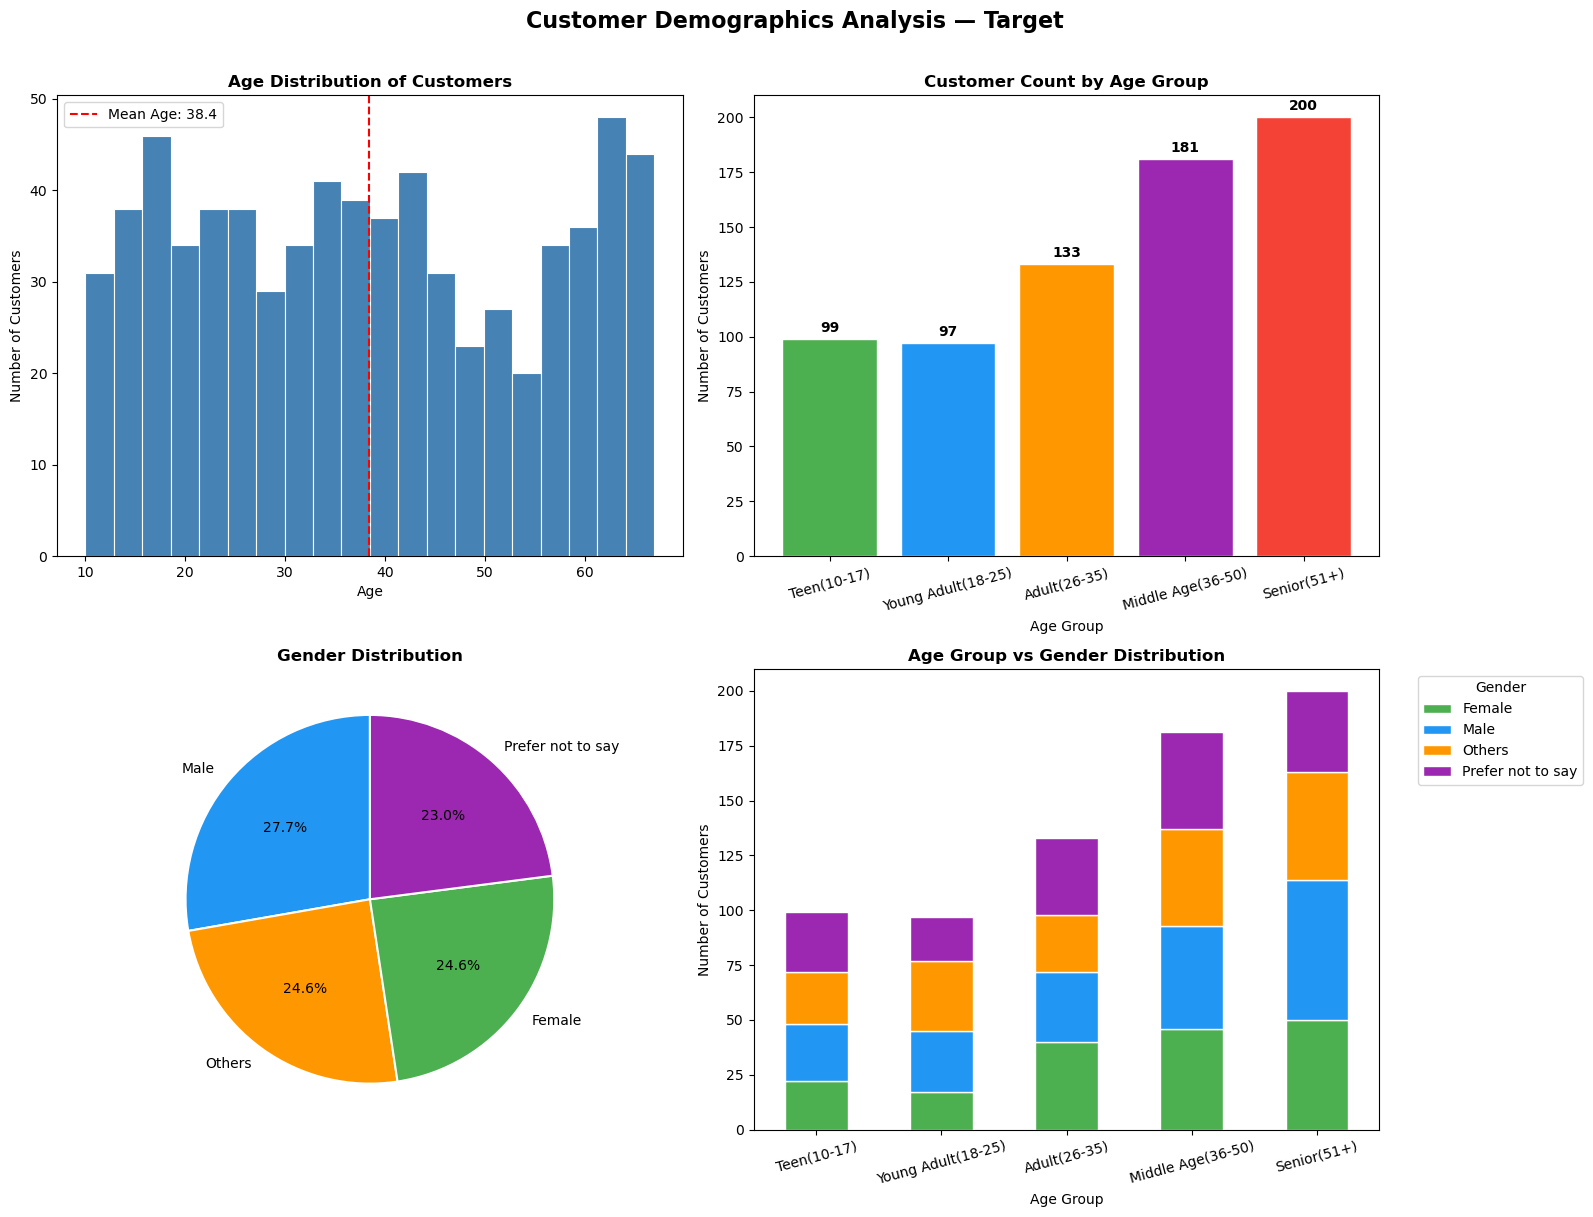

✅ Demographics Visualization Complete!


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Demographics Analysis — Target', 
             fontsize=16, fontweight='bold', y=1.01)

# ============================================================
# PLOT 1 - Age Distribution Histogram
# ============================================================
axes[0, 0].hist(df['age'], bins=20, color='steelblue', 
                edgecolor='white', linewidth=0.8)
axes[0, 0].set_title('Age Distribution of Customers', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].axvline(df['age'].mean(), color='red', 
                   linestyle='--', label=f"Mean Age: {df['age'].mean():.1f}")
axes[0, 0].legend()

# ============================================================
# PLOT 2 - Age Group Bar Chart
# ============================================================
age_group_counts = df['Age_Group'].value_counts().sort_index()
bars = axes[0, 1].bar(age_group_counts.index, age_group_counts.values,
                       color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'],
                       edgecolor='white')
axes[0, 1].set_title('Customer Count by Age Group', fontweight='bold')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, age_group_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + 2, str(val),
                    ha='center', va='bottom', fontweight='bold')

# ============================================================
# PLOT 3 - Gender Pie Chart
# ============================================================
gender_counts = df['Gender'].value_counts()
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
axes[1, 0].pie(gender_counts.values,
               labels=gender_counts.index,
               autopct='%1.1f%%',
               colors=colors,
               startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1, 0].set_title('Gender Distribution', fontweight='bold')

# ============================================================
# PLOT 4 - Age Group vs Gender Stacked Bar
# ============================================================
crosstab = pd.crosstab(df['Age_Group'], df['Gender'])
crosstab.plot(kind='bar', stacked=True, ax=axes[1, 1],
              color=['#4CAF50','#2196F3','#FF9800','#9C27B0'],
              edgecolor='white')
axes[1, 1].set_title('Age Group vs Gender Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('demographics_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Demographics Visualization Complete!")

In [20]:
# ============================================================
# STEP 1 - Overall Purchase Frequency Distribution
# ============================================================
print("=" * 55)
print("PURCHASE FREQUENCY DISTRIBUTION")
print("=" * 55)

freq_order = ['Less than once a month', 'Once a month', 
              'Few times a month', 'Once a week', 
              'Multiple times a week']

freq_counts = df['Purchase_Frequency'].value_counts()
freq_counts = freq_counts.reindex(freq_order)
freq_pct = (freq_counts / len(df) * 100).round(2)

freq_summary = pd.DataFrame({
    'Count'         : freq_counts,
    'Percentage(%)' : freq_pct
})
print(freq_summary)

# ============================================================
# STEP 2 - Explode Purchase Categories (multi-value column)
# ============================================================
print("\n" + "=" * 55)
print("MOST POPULAR PRODUCT CATEGORIES")
print("=" * 55)

# Each row has multiple categories separated by semicolons
# We explode them into individual rows
categories_exploded = df['Purchase_Categories'].str.split(';').explode()
categories_exploded = categories_exploded.str.strip()

category_counts = categories_exploded.value_counts()
category_pct = (category_counts / len(df) * 100).round(2)

category_summary = pd.DataFrame({
    'Count'         : category_counts,
    'Percentage(%)' : category_pct
})
print(category_summary)

# ============================================================
# STEP 3 - Average Purchase Frequency Encoded Score by Category
# ============================================================
print("\n" + "=" * 55)
print("AVG PURCHASE FREQUENCY SCORE BY GENDER")
print("=" * 55)

gender_freq = df.groupby('Gender')['Purchase_Frequency_Encoded'].mean().round(2)
gender_freq = gender_freq.sort_values(ascending=False)
print(gender_freq)

# ============================================================
# STEP 4 - Purchase Frequency by Age Group
# ============================================================
print("\n" + "=" * 55)
print("AVG PURCHASE FREQUENCY SCORE BY AGE GROUP")
print("=" * 55)

age_freq = df.groupby('Age_Group', observed=True)['Purchase_Frequency_Encoded'].mean().round(2)
print(age_freq)

PURCHASE FREQUENCY DISTRIBUTION
                        Count  Percentage(%)
Purchase_Frequency                          
Less than once a month    148          20.85
Once a month              143          20.14
Few times a month         139          19.58
Once a week               131          18.45
Multiple times a week     149          20.99

MOST POPULAR PRODUCT CATEGORIES
                            Count  Percentage(%)
Purchase_Categories                             
Clothing and Fashion          378          53.24
Beauty and Personal Care      377          53.10
Groceries and Gourmet Food    357          50.28
Home and Kitchen              357          50.28
others                        348          49.01

AVG PURCHASE FREQUENCY SCORE BY GENDER
Gender
Female               3.13
Male                 3.09
Others               3.05
Prefer not to say    2.64
Name: Purchase_Frequency_Encoded, dtype: float64

AVG PURCHASE FREQUENCY SCORE BY AGE GROUP
Age_Group
Teen(10-17)           3.

In [21]:
# ============================================================
# STEP 1 - Browsing Frequency Distribution
# ============================================================
print("=" * 55)
print("BROWSING FREQUENCY DISTRIBUTION")
print("=" * 55)

browse_order = ['Rarely', 'Few times a month', 
                'Few times a week', 'Multiple times a day']

browse_counts = df['Browsing_Frequency'].value_counts()
browse_counts = browse_counts.reindex(browse_order)
browse_pct = (browse_counts / len(df) * 100).round(2)

browse_summary = pd.DataFrame({
    'Count'         : browse_counts,
    'Percentage(%)' : browse_pct
})
print(browse_summary)

# ============================================================
# STEP 2 - Product Search Method Distribution
# ============================================================
print("\n" + "=" * 55)
print("PRODUCT SEARCH METHOD DISTRIBUTION")
print("=" * 55)

search_counts = df['Product_Search_Method'].value_counts()
search_pct = (search_counts / len(df) * 100).round(2)

search_summary = pd.DataFrame({
    'Count'         : search_counts,
    'Percentage(%)' : search_pct
})
print(search_summary)

# ============================================================
# STEP 3 - Search Result Exploration
# ============================================================
print("\n" + "=" * 55)
print("SEARCH RESULT EXPLORATION BEHAVIOR")
print("=" * 55)

explore_counts = df['Search_Result_Exploration'].value_counts()
explore_pct = (explore_counts / len(df) * 100).round(2)

explore_summary = pd.DataFrame({
    'Count'         : explore_counts,
    'Percentage(%)' : explore_pct
})
print(explore_summary)

# ============================================================
# STEP 4 - Cart Abandonment Factors
# ============================================================
print("\n" + "=" * 55)
print("CART ABANDONMENT FACTORS")
print("=" * 55)

abandon_counts = df['Cart_Abandonment_Factors'].value_counts()
abandon_pct = (abandon_counts / len(df) * 100).round(2)

abandon_summary = pd.DataFrame({
    'Count'         : abandon_counts,
    'Percentage(%)' : abandon_pct
})
print(abandon_summary)

# ============================================================
# STEP 5 - Cart Abandonment by Age Group
# ============================================================
print("\n" + "=" * 55)
print("CART ABANDONMENT FACTORS BY AGE GROUP")
print("=" * 55)

abandon_age = pd.crosstab(df['Age_Group'], 
                           df['Cart_Abandonment_Factors'])
print(abandon_age)

# ============================================================
# STEP 6 - Add to Cart vs Cart Completion
# ============================================================
print("\n" + "=" * 55)
print("ADD TO CART BROWSING vs CART COMPLETION")
print("=" * 55)

cart_cross = pd.crosstab(df['Add_to_Cart_Browsing'],
                          df['Cart_Completion_Frequency'])
print(cart_cross)

BROWSING FREQUENCY DISTRIBUTION
                      Count  Percentage(%)
Browsing_Frequency                        
Rarely                  172          24.23
Few times a month       182          25.63
Few times a week        175          24.65
Multiple times a day    181          25.49

PRODUCT SEARCH METHOD DISTRIBUTION
                       Count  Percentage(%)
Product_Search_Method                      
Others                   306          43.10
Keyword                  145          20.42
Filter                   139          19.58
Categories               120          16.90

SEARCH RESULT EXPLORATION BEHAVIOR
                           Count  Percentage(%)
Search_Result_Exploration                      
First page                   376          52.96
Multiple pages               334          47.04

CART ABANDONMENT FACTORS
                                            Count  Percentage(%)
Cart_Abandonment_Factors                                        
High Shipping Costs       

In [22]:
# ============================================================
# STEP 1 - Mean & Median of Core Rating Columns
# ============================================================
print("=" * 55)
print("SATISFACTION & RATING METRICS SUMMARY")
print("=" * 55)

rating_cols = ['Shopping_Satisfaction', 
               'Personalized_Recommendation_Rating',
               'Rating_Accuracy',
               'Customer_Reviews_Importance']

for col in rating_cols:
    print(f"\n{col}:")
    print(f"  Mean   : {df[col].mean():.2f}")
    print(f"  Median : {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Min    : {df[col].min()}")
    print(f"  Max    : {df[col].max()}")

# ============================================================
# STEP 2 - Recommendation Helpfulness Distribution
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION HELPFULNESS DISTRIBUTION")
print("=" * 55)

rec_help = df['Recommendation_Helpfulness'].value_counts()
rec_help_pct = (rec_help / len(df) * 100).round(2)
rec_summary = pd.DataFrame({
    'Count'         : rec_help,
    'Percentage(%)' : rec_help_pct
})
print(rec_summary)

# ============================================================
# STEP 3 - Satisfaction by Age Group
# ============================================================
print("\n" + "=" * 55)
print("AVG SHOPPING SATISFACTION BY AGE GROUP")
print("=" * 55)

sat_age = df.groupby('Age_Group', observed=True)['Shopping_Satisfaction'].agg(['mean','median']).round(2)
print(sat_age)

# ============================================================
# STEP 4 - Satisfaction by Gender
# ============================================================
print("\n" + "=" * 55)
print("AVG SHOPPING SATISFACTION BY GENDER")
print("=" * 55)

sat_gender = df.groupby('Gender')['Shopping_Satisfaction'].agg(['mean','median']).round(2)
print(sat_gender)

# ============================================================
# STEP 5 - Rating Accuracy by Purchase Frequency
# ============================================================
print("\n" + "=" * 55)
print("AVG RATING ACCURACY BY PURCHASE FREQUENCY")
print("=" * 55)

rat_freq = df.groupby('Purchase_Frequency')['Rating_Accuracy'].agg(['mean','median']).round(2)
print(rat_freq)

SATISFACTION & RATING METRICS SUMMARY

Shopping_Satisfaction:
  Mean   : 2.96
  Median : 3.00
  Std Dev: 1.44
  Min    : 1
  Max    : 5

Personalized_Recommendation_Rating:
  Mean   : 2.98
  Median : 3.00
  Std Dev: 1.44
  Min    : 1
  Max    : 5

Rating_Accuracy:
  Mean   : 3.05
  Median : 3.00
  Std Dev: 1.44
  Min    : 1
  Max    : 5

Customer_Reviews_Importance:
  Mean   : 3.00
  Median : 3.00
  Std Dev: 1.43
  Min    : 1
  Max    : 5

RECOMMENDATION HELPFULNESS DISTRIBUTION
                            Count  Percentage(%)
Recommendation_Helpfulness                      
No                            241          33.94
Yes                           235          33.10
Sometimes                     234          32.96

AVG SHOPPING SATISFACTION BY AGE GROUP
                    mean  median
Age_Group                       
Teen(10-17)         3.17     3.0
Young Adult(18-25)  2.89     3.0
Adult(26-35)        2.83     3.0
Middle Age(36-50)   2.85     3.0
Senior(51+)         3.08     3.0


C:\Users\Ayush\AppData\Local\Temp\ipykernel_104348\448743275.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 0].boxplot(rating_data, patch_artist=True,


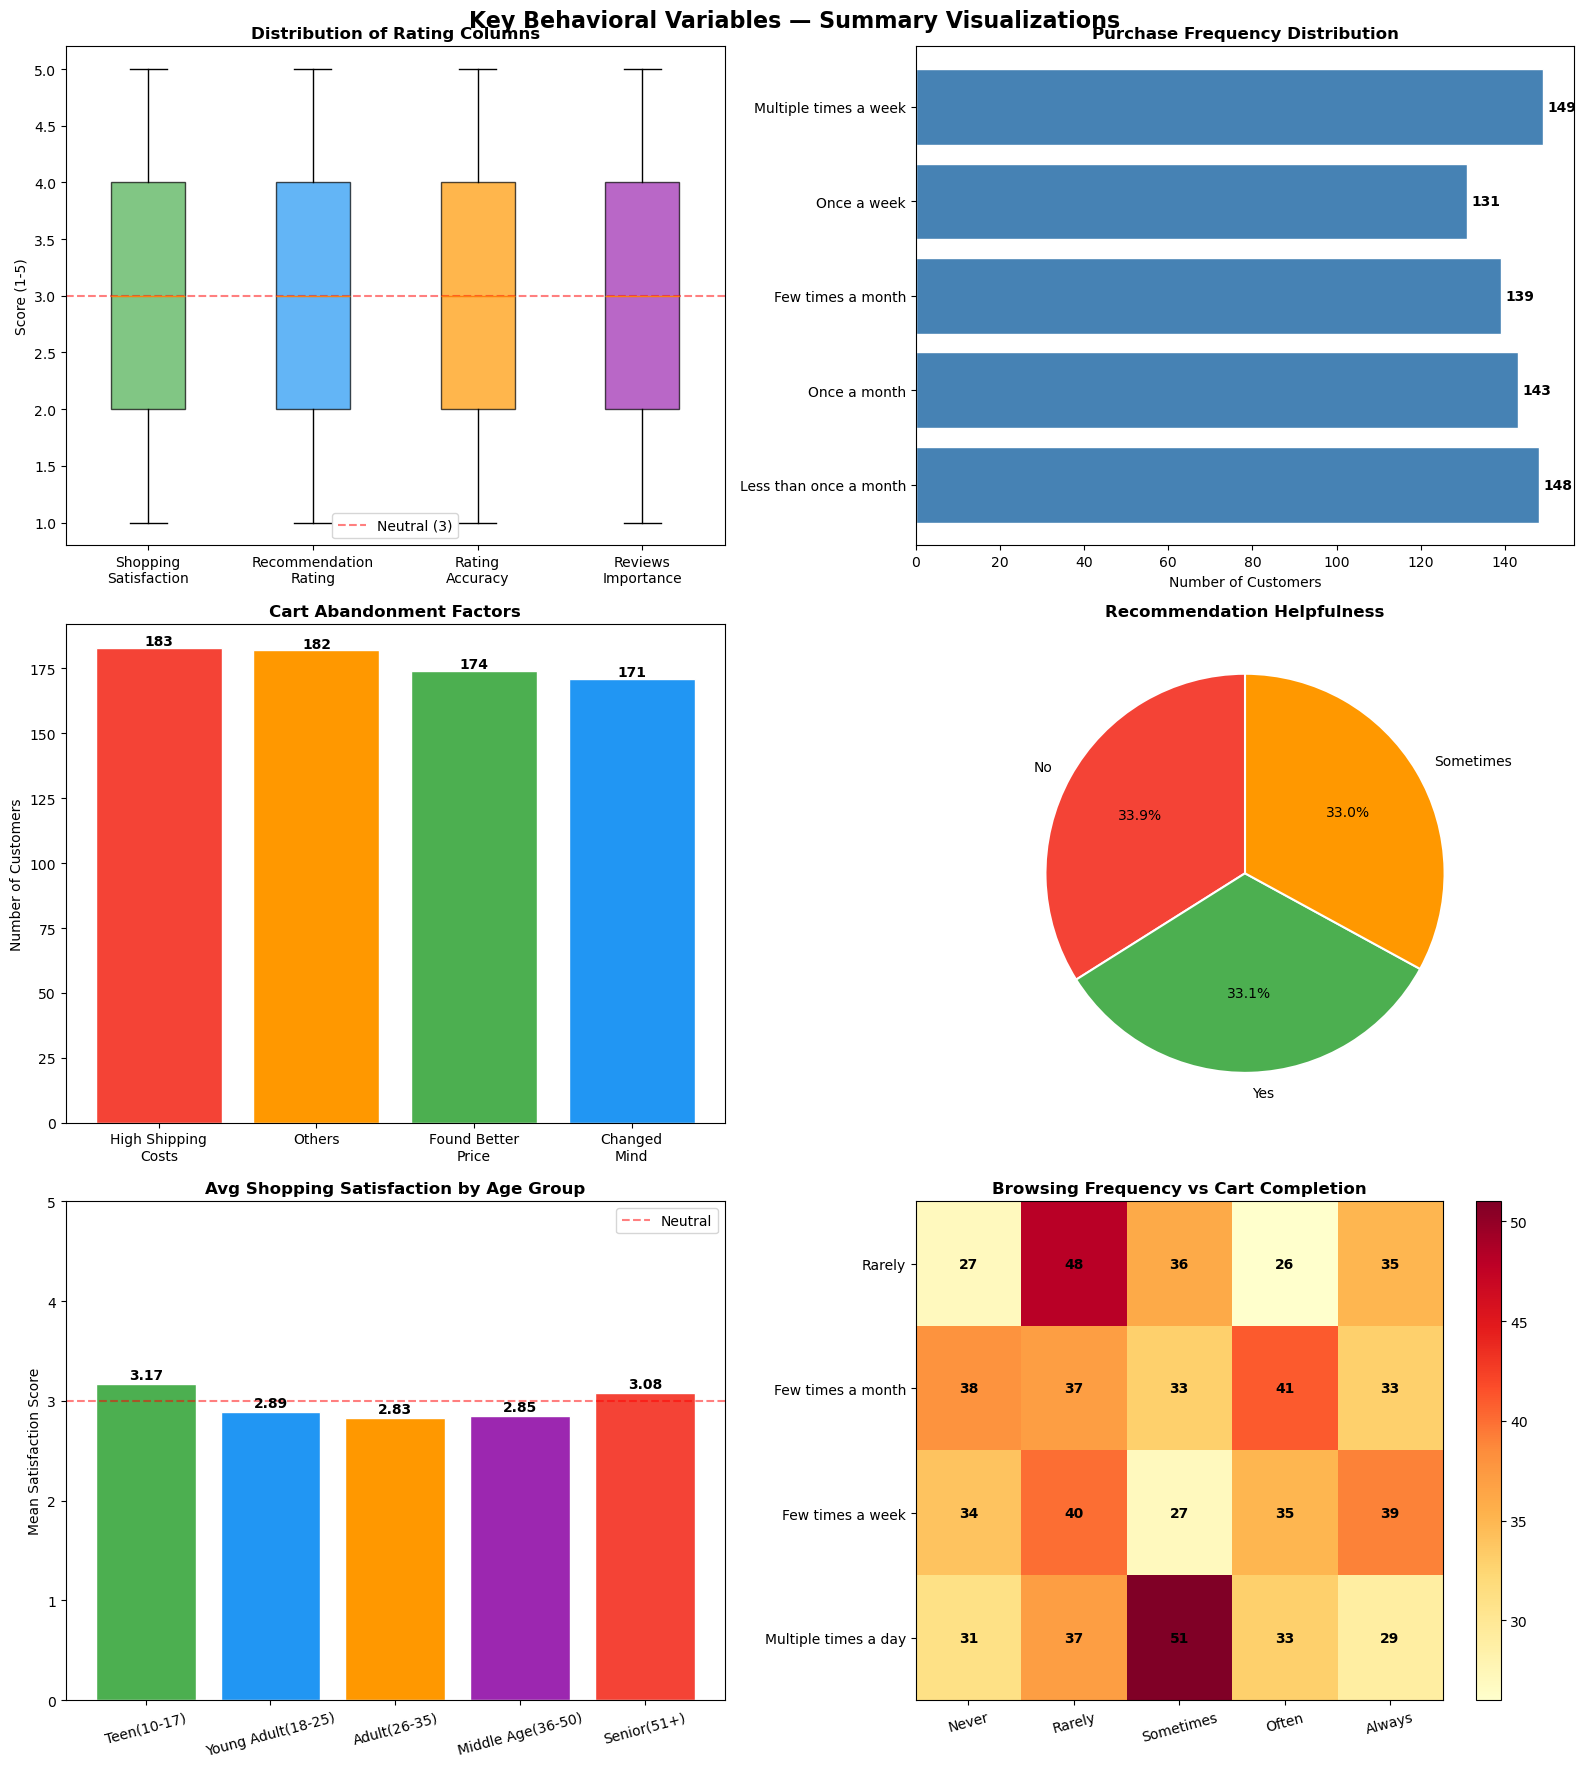

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Key Behavioral Variables — Summary Visualizations', 
             fontsize=16, fontweight='bold')

# ============================================================
# PLOT 1 - Rating Columns Distribution (Box Plot)
# ============================================================
rating_cols = ['Shopping_Satisfaction', 
               'Personalized_Recommendation_Rating',
               'Rating_Accuracy',
               'Customer_Reviews_Importance']

rating_data = [df[col].dropna().astype(float).tolist() for col in rating_cols]
bp = axes[0, 0].boxplot(rating_data, patch_artist=True,
                         labels=['Shopping\nSatisfaction', 
                                 'Recommendation\nRating',
                                 'Rating\nAccuracy',
                                 'Reviews\nImportance'])
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 0].set_title('Distribution of Rating Columns', fontweight='bold')
axes[0, 0].set_ylabel('Score (1-5)')
axes[0, 0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Neutral (3)')
axes[0, 0].legend()

# ============================================================
# PLOT 2 - Purchase Frequency Bar Chart
# ============================================================
freq_order = ['Less than once a month', 'Once a month',
              'Few times a month', 'Once a week',
              'Multiple times a week']
freq_counts = df['Purchase_Frequency'].value_counts().reindex(freq_order)
bars = axes[0, 1].barh(freq_order, freq_counts.values,
                        color='steelblue', edgecolor='white')
axes[0, 1].set_title('Purchase Frequency Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Number of Customers')
for bar, val in zip(bars, freq_counts.values):
    axes[0, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontweight='bold')

# ============================================================
# PLOT 3 - Cart Abandonment Factors
# ============================================================
abandon_counts = df['Cart_Abandonment_Factors'].value_counts()
short_labels = ['High Shipping\nCosts', 'Others', 
                'Found Better\nPrice', 'Changed\nMind']
bars2 = axes[1, 0].bar(short_labels, abandon_counts.values,
                        color=['#F44336','#FF9800','#4CAF50','#2196F3'],
                        edgecolor='white')
axes[1, 0].set_title('Cart Abandonment Factors', fontweight='bold')
axes[1, 0].set_ylabel('Number of Customers')
for bar, val in zip(bars2, abandon_counts.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1, str(val),
                    ha='center', fontweight='bold')

# ============================================================
# PLOT 4 - Recommendation Helpfulness Pie
# ============================================================
rec_help = df['Recommendation_Helpfulness'].value_counts()
axes[1, 1].pie(rec_help.values,
               labels=rec_help.index,
               autopct='%1.1f%%',
               colors=['#F44336','#4CAF50','#FF9800'],
               startangle=90,
               wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1, 1].set_title('Recommendation Helpfulness', fontweight='bold')

# ============================================================
# PLOT 5 - Avg Satisfaction by Age Group
# ============================================================
sat_age = df.groupby('Age_Group', observed=True)['Shopping_Satisfaction'].mean()
bars3 = axes[2, 0].bar(sat_age.index, sat_age.values,
                        color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'],
                        edgecolor='white')
axes[2, 0].set_title('Avg Shopping Satisfaction by Age Group', fontweight='bold')
axes[2, 0].set_ylabel('Mean Satisfaction Score')
axes[2, 0].set_ylim(0, 5)
axes[2, 0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Neutral')
axes[2, 0].tick_params(axis='x', rotation=15)
axes[2, 0].legend()
for bar, val in zip(bars3, sat_age.values):
    axes[2, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05, f'{val:.2f}',
                    ha='center', fontweight='bold')

# ============================================================
# PLOT 6 - Browsing Frequency vs Cart Completion Heatmap
# ============================================================
heat_data = pd.crosstab(df['Browsing_Frequency'], 
                         df['Cart_Completion_Frequency'])
browse_order  = ['Rarely','Few times a month',
                 'Few times a week','Multiple times a day']
cart_order    = ['Never','Rarely','Sometimes','Often','Always']
heat_data = heat_data.reindex(index=browse_order, columns=cart_order)

im = axes[2, 1].imshow(heat_data.values, cmap='YlOrRd', aspect='auto')
axes[2, 1].set_xticks(range(len(cart_order)))
axes[2, 1].set_xticklabels(cart_order, rotation=15)
axes[2, 1].set_yticks(range(len(browse_order)))
axes[2, 1].set_yticklabels(browse_order)
axes[2, 1].set_title('Browsing Frequency vs Cart Completion', fontweight='bold')
plt.colorbar(im, ax=axes[2, 1])
for i in range(len(browse_order)):
    for j in range(len(cart_order)):
        axes[2, 1].text(j, i, str(heat_data.values[i, j]),
                        ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('behavioral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 1 - Prepare Segmentation Columns
# ============================================================
seg_df = df[['Purchase_Frequency_Encoded', 
             'Shopping_Satisfaction']].copy().astype(float)

print("=" * 55)
print("SEGMENTATION BASE COLUMNS")
print("=" * 55)
print(seg_df.describe().round(2))

# ============================================================
# STEP 2 - Create Frequency Segments (Low/Medium/High)
# ============================================================
df['Frequency_Segment'] = pd.cut(
    df['Purchase_Frequency_Encoded'],
    bins=[0, 2, 3, 5],
    labels=['Low Frequency', 'Medium Frequency', 'High Frequency']
)

print("\n" + "=" * 55)
print("PURCHASE FREQUENCY SEGMENTS")
print("=" * 55)
freq_seg = df['Frequency_Segment'].value_counts().sort_index()
freq_seg_pct = (freq_seg / len(df) * 100).round(2)
print(pd.DataFrame({'Count': freq_seg, 'Percentage(%)': freq_seg_pct}))

# ============================================================
# STEP 3 - Create Satisfaction Segments (Low/Medium/High)
# ============================================================
df['Satisfaction_Segment'] = pd.cut(
    df['Shopping_Satisfaction'].astype(float),
    bins=[0, 2, 3, 5],
    labels=['Low Satisfaction', 'Medium Satisfaction', 'High Satisfaction']
)

print("\n" + "=" * 55)
print("SHOPPING SATISFACTION SEGMENTS")
print("=" * 55)
sat_seg = df['Satisfaction_Segment'].value_counts().sort_index()
sat_seg_pct = (sat_seg / len(df) * 100).round(2)
print(pd.DataFrame({'Count': sat_seg, 'Percentage(%)': sat_seg_pct}))

# ============================================================
# STEP 4 - Combined Segment Profile
# ============================================================
print("\n" + "=" * 55)
print("COMBINED SEGMENT PROFILE")
print("=" * 55)
combined = pd.crosstab(df['Frequency_Segment'], 
                        df['Satisfaction_Segment'])
print(combined)

# ============================================================
# STEP 5 - Create Master Segment Label
# ============================================================
df['Customer_Segment'] = df['Frequency_Segment'].astype(str) + \
                          ' + ' + df['Satisfaction_Segment'].astype(str)

print("\n" + "=" * 55)
print("MASTER CUSTOMER SEGMENTS — TOP 9")
print("=" * 55)
segment_counts = df['Customer_Segment'].value_counts()
print(segment_counts)

# ============================================================
# STEP 6 - Segment Profile Summary
# ============================================================
print("\n" + "=" * 55)
print("SEGMENT PROFILE — AVG METRICS")
print("=" * 55)
profile = df.groupby('Frequency_Segment', observed=True).agg(
    Avg_Satisfaction    = ('Shopping_Satisfaction', 'mean'),
    Avg_Rating_Accuracy = ('Rating_Accuracy', 'mean'),
    Avg_Reviews_Imp     = ('Customer_Reviews_Importance', 'mean'),
    Customer_Count      = ('transaction', 'count')
).round(2)
print(profile)

SEGMENTATION BASE COLUMNS
       Purchase_Frequency_Encoded  Shopping_Satisfaction
count                      710.00                 710.00
mean                         2.99                   2.96
std                          1.44                   1.44
min                          1.00                   1.00
25%                          2.00                   2.00
50%                          3.00                   3.00
75%                          4.00                   4.00
max                          5.00                   5.00

PURCHASE FREQUENCY SEGMENTS
                   Count  Percentage(%)
Frequency_Segment                      
Low Frequency        291          40.99
Medium Frequency     139          19.58
High Frequency       280          39.44

SHOPPING SATISFACTION SEGMENTS
                      Count  Percentage(%)
Satisfaction_Segment                      
Low Satisfaction        293          41.27
Medium Satisfaction     152          21.41
High Satisfaction       265 

In [26]:
# ============================================================
# STEP 1 - Define Profile Assignment Function
# ============================================================

def assign_profile(row):
    freq = row['Purchase_Frequency_Encoded']
    sat  = row['Shopping_Satisfaction']
    cart = row['Cart_Abandonment_Factors']
    
    # Frequent Buyers: High frequency + High satisfaction
    if freq >= 4 and sat >= 4:
        return 'Frequent Buyer'
    
    # Occasional Shoppers: Medium frequency + Moderate satisfaction
    elif freq == 3 and 2 <= sat <= 3:
        return 'Occasional Shopper'
    
    # At-Risk: Low satisfaction OR frequent cart abandonment
    elif sat <= 2 or cart in ['High Shipping Costs', 
                               'Found A Better Price Elsewhere']:
        return 'At-Risk Customer'
    
    # Engaged Browsers: High browsing but moderate purchase
    elif freq <= 2 and sat >= 4:
        return 'Potential Converter'
    
    # Default
    else:
        return 'Neutral Customer'

df['Customer_Profile'] = df.apply(assign_profile, axis=1)

print("=" * 55)
print("CUSTOMER PROFILE DISTRIBUTION")
print("=" * 55)
profile_counts = df['Customer_Profile'].value_counts()
profile_pct    = (profile_counts / len(df) * 100).round(2)
print(pd.DataFrame({
    'Count'         : profile_counts,
    'Percentage(%)' : profile_pct
}))

# ============================================================
# STEP 2 - Profile wise Average Metrics
# ============================================================
print("\n" + "=" * 55)
print("PROFILE-WISE AVERAGE METRICS")
print("=" * 55)

profile_summary = df.groupby('Customer_Profile').agg(
    Count                = ('transaction', 'count'),
    Avg_Age              = ('age', 'mean'),
    Avg_Satisfaction     = ('Shopping_Satisfaction', 'mean'),
    Avg_Purchase_Freq    = ('Purchase_Frequency_Encoded', 'mean'),
    Avg_Browsing_Freq    = ('Browsing_Frequency_Encoded', 'mean'),
    Avg_Cart_Completion  = ('Cart_Completion_Encoded', 'mean'),
    Avg_Rating_Accuracy  = ('Rating_Accuracy', 'mean')
).round(2)
print(profile_summary)

# ============================================================
# STEP 3 - Profile by Gender
# ============================================================
print("\n" + "=" * 55)
print("CUSTOMER PROFILE BY GENDER")
print("=" * 55)
profile_gender = pd.crosstab(df['Customer_Profile'], df['Gender'])
print(profile_gender)

# ============================================================
# STEP 4 - Profile by Age Group
# ============================================================
print("\n" + "=" * 55)
print("CUSTOMER PROFILE BY AGE GROUP")
print("=" * 55)
profile_age = pd.crosstab(df['Customer_Profile'], 
                           df['Age_Group'])
print(profile_age)

# ============================================================
# STEP 5 - Top Purchase Category per Profile
# ============================================================
print("\n" + "=" * 55)
print("TOP PURCHASE CATEGORIES PER PROFILE")
print("=" * 55)

for profile in df['Customer_Profile'].unique():
    subset = df[df['Customer_Profile'] == profile]
    cats = subset['Purchase_Categories'].str.split(';').explode().str.strip()
    top_cat = cats.value_counts().idxmax()
    print(f"  {profile:25s} → Top Category: {top_cat}")

CUSTOMER PROFILE DISTRIBUTION
                     Count  Percentage(%)
Customer_Profile                         
At-Risk Customer       436          61.41
Frequent Buyer          99          13.94
Neutral Customer        75          10.56
Occasional Shopper      50           7.04
Potential Converter     50           7.04

PROFILE-WISE AVERAGE METRICS
                     Count  Avg_Age  Avg_Satisfaction  Avg_Purchase_Freq  \
Customer_Profile                                                           
At-Risk Customer       436    38.06              2.37               2.78   
Frequent Buyer          99    39.77              4.54               4.51   
Neutral Customer        75    39.04              3.52               3.21   
Occasional Shopper      50    40.48              2.52               3.00   
Potential Converter     50    35.18              4.62               1.40   

                     Avg_Browsing_Freq  Avg_Cart_Completion  \
Customer_Profile                                  

In [27]:
# ============================================================
# STEP 1 - Age Distribution per Profile
# ============================================================
print("=" * 55)
print("AGE STATISTICS BY CUSTOMER PROFILE")
print("=" * 55)

age_profile = df.groupby('Customer_Profile')['age'].agg(
    Mean_Age   = 'mean',
    Median_Age = 'median',
    Min_Age    = 'min',
    Max_Age    = 'max',
    Std_Age    = 'std'
).round(2)
print(age_profile)

# ============================================================
# STEP 2 - Gender Distribution per Profile (%)
# ============================================================
print("\n" + "=" * 55)
print("GENDER DISTRIBUTION BY PROFILE (%)")
print("=" * 55)

gender_profile_pct = pd.crosstab(df['Customer_Profile'], 
                                  df['Gender'],
                                  normalize='index').round(3) * 100
print(gender_profile_pct.round(2))

# ============================================================
# STEP 3 - Browsing & Cart Behavior per Profile
# ============================================================
print("\n" + "=" * 55)
print("BEHAVIORAL METRICS BY PROFILE")
print("=" * 55)

behavior = df.groupby('Customer_Profile').agg(
    Avg_Browsing           = ('Browsing_Frequency_Encoded', 'mean'),
    Avg_Cart_Completion    = ('Cart_Completion_Encoded', 'mean'),
    Avg_Save_For_Later     = ('Saveforlater_Encoded', 'mean'),
    Avg_Review_Reliability = ('Review_Reliability_Encoded', 'mean'),
    Pct_Review_Left        = ('Review_Left', lambda x: 
                              (x == 'Yes').sum() / len(x) * 100)
).round(2)
print(behavior)

# ============================================================
# STEP 4 - Search Behavior per Profile
# ============================================================
print("\n" + "=" * 55)
print("SEARCH METHOD BY PROFILE (%)")
print("=" * 55)

search_profile = pd.crosstab(df['Customer_Profile'],
                              df['Product_Search_Method'],
                              normalize='index').round(3) * 100
print(search_profile.round(2))

# ============================================================
# STEP 5 - Cart Abandonment per Profile (%)
# ============================================================
print("\n" + "=" * 55)
print("CART ABANDONMENT FACTORS BY PROFILE (%)")
print("=" * 55)

abandon_profile = pd.crosstab(df['Customer_Profile'],
                               df['Cart_Abandonment_Factors'],
                               normalize='index').round(3) * 100
print(abandon_profile.round(2))

# ============================================================
# STEP 6 - Recommendation Helpfulness per Profile (%)
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION HELPFULNESS BY PROFILE (%)")
print("=" * 55)

rec_profile = pd.crosstab(df['Customer_Profile'],
                           df['Recommendation_Helpfulness'],
                           normalize='index').round(3) * 100
print(rec_profile.round(2))

AGE STATISTICS BY CUSTOMER PROFILE
                     Mean_Age  Median_Age  Min_Age  Max_Age  Std_Age
Customer_Profile                                                    
At-Risk Customer        38.06        36.0       10       67    16.41
Frequent Buyer          39.77        41.0       10       67    17.89
Neutral Customer        39.04        37.0       11       67    16.94
Occasional Shopper      40.48        43.5       10       67    17.91
Potential Converter     35.18        33.0       10       67    18.47

GENDER DISTRIBUTION BY PROFILE (%)
Gender               Female  Male  Others  Prefer not to say
Customer_Profile                                            
At-Risk Customer       24.3  26.4    22.7               26.6
Frequent Buyer         24.2  32.3    29.3               14.1
Neutral Customer       24.0  30.7    32.0               13.3
Occasional Shopper     32.0  30.0    24.0               14.0
Potential Converter    22.0  24.0    22.0               32.0

BEHAVIORAL METRICS

CLUSTERING FEATURE SET
Features used : 10
Rows          : 710
Missing values: 0

✅ Features scaled successfully

ELBOW METHOD & SILHOUETTE SCORES
  K=2 | Inertia: 6524.36 | Silhouette: 0.0791
  K=3 | Inertia: 6143.08 | Silhouette: 0.0734
  K=4 | Inertia: 5852.55 | Silhouette: 0.0763
  K=5 | Inertia: 5609.54 | Silhouette: 0.0766
  K=6 | Inertia: 5387.45 | Silhouette: 0.0782
  K=7 | Inertia: 5230.60 | Silhouette: 0.0795
  K=8 | Inertia: 5069.89 | Silhouette: 0.0779
  K=9 | Inertia: 4905.69 | Silhouette: 0.0837


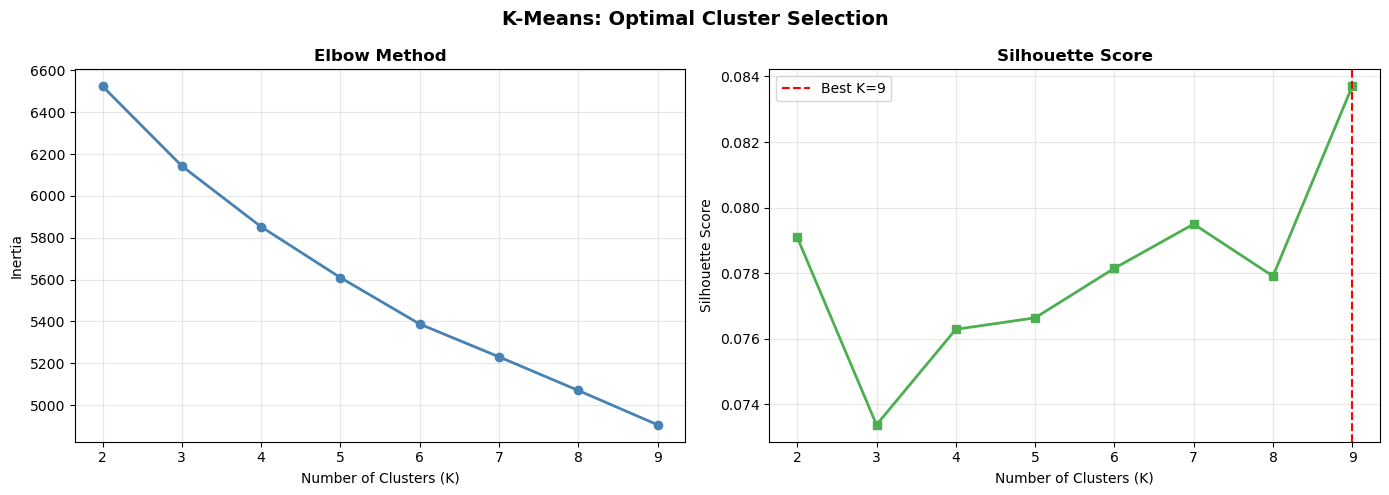


✅ Best K based on Silhouette Score: 9


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1 - Select Features for Clustering
# ============================================================
cluster_features = [
    'Purchase_Frequency_Encoded',
    'Browsing_Frequency_Encoded',
    'Cart_Completion_Encoded',
    'Saveforlater_Encoded',
    'Review_Reliability_Encoded',
    'Customer_Reviews_Importance',
    'Shopping_Satisfaction',
    'Rating_Accuracy',
    'Personalized_Recommendation_Rating',
    'Personalized_Recommendation_Frequency'
]

X = df[cluster_features].copy().astype(float)
print("=" * 55)
print("CLUSTERING FEATURE SET")
print("=" * 55)
print(f"Features used : {len(cluster_features)}")
print(f"Rows          : {X.shape[0]}")
print(f"Missing values: {X.isnull().sum().sum()}")

# ============================================================
# STEP 2 - Scale the Features
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n✅ Features scaled successfully")

# ============================================================
# STEP 3 - Elbow Method to Find Optimal K
# ============================================================
inertia_values    = []
silhouette_values = []
k_range           = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, km.labels_))

print("\n" + "=" * 55)
print("ELBOW METHOD & SILHOUETTE SCORES")
print("=" * 55)
for k, inertia, sil in zip(k_range, inertia_values, silhouette_values):
    print(f"  K={k} | Inertia: {inertia:.2f} | Silhouette: {sil:.4f}")

# ============================================================
# STEP 4 - Plot Elbow & Silhouette
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means: Optimal Cluster Selection', 
             fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), inertia_values, 
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_values,
             marker='s', color='#4CAF50', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

best_k = k_range.start + silhouette_values.index(max(silhouette_values))
axes[1].axvline(x=best_k, color='red', linestyle='--',
                label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Best K based on Silhouette Score: {best_k}")

KMEANS CLUSTERING — K=4
                Count  Percentage(%)
KMeans_Cluster                      
0                 161          22.68
1                 183          25.77
2                 191          26.90
3                 175          24.65

CLUSTER PROFILE — AVG METRICS
                Count  Avg_Age  Avg_Purchase_Freq  Avg_Browsing  \
KMeans_Cluster                                                    
0                 161    40.51               3.20          1.74   
1                 183    39.38               2.89          2.28   
2                 191    37.67               2.84          2.74   
3                 175    36.10               3.05          3.23   

                Avg_Cart_Completion  Avg_Satisfaction  Avg_Rating_Accuracy  \
KMeans_Cluster                                                               
0                              3.30              3.38                 2.42   
1                              3.13              2.54                 2.75   
2       

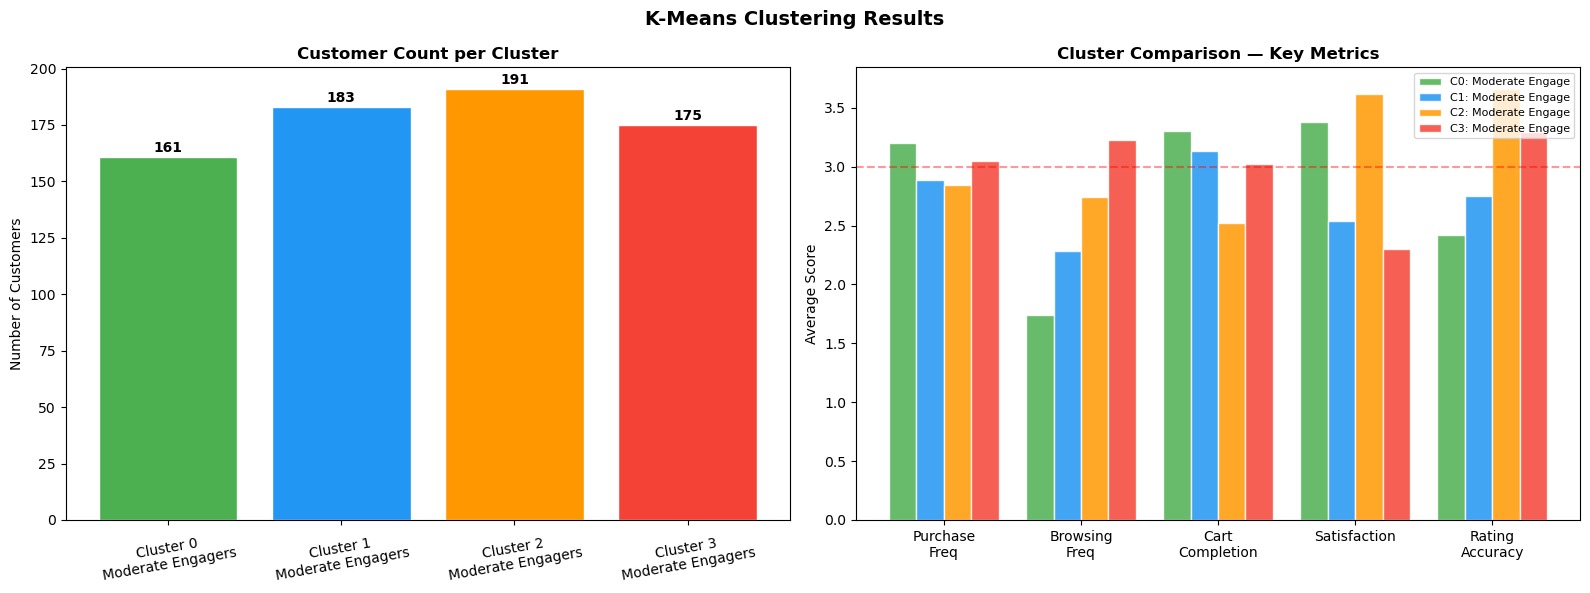


✅ K-Means Clustering Complete!


In [29]:
# ============================================================
# STEP 1 - Fit Final KMeans with K=4
# ============================================================
optimal_k = 4
km_final  = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_final.fit_predict(X_scaled)

print("=" * 55)
print(f"KMEANS CLUSTERING — K={optimal_k}")
print("=" * 55)
cluster_counts = df['KMeans_Cluster'].value_counts().sort_index()
cluster_pct    = (cluster_counts / len(df) * 100).round(2)
print(pd.DataFrame({
    'Count'         : cluster_counts,
    'Percentage(%)' : cluster_pct
}))

# ============================================================
# STEP 2 - Cluster Profile on Key Metrics
# ============================================================
print("\n" + "=" * 55)
print("CLUSTER PROFILE — AVG METRICS")
print("=" * 55)

cluster_profile = df.groupby('KMeans_Cluster').agg(
    Count                    = ('transaction', 'count'),
    Avg_Age                  = ('age', 'mean'),
    Avg_Purchase_Freq        = ('Purchase_Frequency_Encoded', 'mean'),
    Avg_Browsing             = ('Browsing_Frequency_Encoded', 'mean'),
    Avg_Cart_Completion      = ('Cart_Completion_Encoded', 'mean'),
    Avg_Satisfaction         = ('Shopping_Satisfaction', 'mean'),
    Avg_Rating_Accuracy      = ('Rating_Accuracy', 'mean'),
    Avg_Rec_Rating           = ('Personalized_Recommendation_Rating', 'mean'),
    Avg_Reviews_Importance   = ('Customer_Reviews_Importance', 'mean')
).round(2)
print(cluster_profile)

# ============================================================
# STEP 3 - Assign Business Labels to Clusters
# ============================================================
print("\n" + "=" * 55)
print("CLUSTER BUSINESS LABEL ASSIGNMENT")
print("=" * 55)

# Label based on purchase frequency + satisfaction profile
cluster_labels = {}
for cluster in range(optimal_k):
    freq = cluster_profile.loc[cluster, 'Avg_Purchase_Freq']
    sat  = cluster_profile.loc[cluster, 'Avg_Satisfaction']
    
    if freq >= 3.5 and sat >= 3.5:
        label = 'High Value Loyalists'
    elif freq >= 3.5 and sat < 3.0:
        label = 'Frequent but Dissatisfied'
    elif freq < 2.5 and sat >= 3.5:
        label = 'Satisfied Rare Shoppers'
    elif freq < 2.5 and sat < 3.0:
        label = 'Disengaged At-Risk'
    else:
        label = 'Moderate Engagers'
        
    cluster_labels[cluster] = label
    print(f"  Cluster {cluster} → {label} "
          f"(Freq: {freq:.2f}, Sat: {sat:.2f})")

df['Cluster_Label'] = df['KMeans_Cluster'].map(cluster_labels)

# ============================================================
# STEP 4 - Cluster Label Distribution
# ============================================================
print("\n" + "=" * 55)
print("CLUSTER LABEL DISTRIBUTION")
print("=" * 55)
label_dist = df['Cluster_Label'].value_counts()
label_pct  = (label_dist / len(df) * 100).round(2)
print(pd.DataFrame({
    'Count'         : label_dist,
    'Percentage(%)' : label_pct
}))

# ============================================================
# STEP 5 - Cluster vs Customer Profile Cross Tab
# ============================================================
print("\n" + "=" * 55)
print("KMEANS CLUSTERS vs CUSTOMER PROFILES")
print("=" * 55)
cross = pd.crosstab(df['Cluster_Label'], df['Customer_Profile'])
print(cross)

# ============================================================
# STEP 6 - Visualize Clusters
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering Results', 
             fontsize=14, fontweight='bold')

# Plot 1 - Cluster sizes
colors = ['#4CAF50','#2196F3','#FF9800','#F44336']
bars = axes[0].bar(
    [f"Cluster {i}\n{cluster_labels[i]}" for i in range(optimal_k)],
    cluster_counts.values,
    color=colors, edgecolor='white'
)
axes[0].set_title('Customer Count per Cluster', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=10)
for bar, val in zip(bars, cluster_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2, str(val),
                 ha='center', fontweight='bold')

# Plot 2 - Radar-style grouped bar for key metrics
metrics      = ['Avg_Purchase_Freq','Avg_Browsing',
                'Avg_Cart_Completion','Avg_Satisfaction',
                'Avg_Rating_Accuracy']
metric_names = ['Purchase\nFreq','Browsing\nFreq',
                'Cart\nCompletion','Satisfaction',
                'Rating\nAccuracy']

x     = range(len(metrics))
width = 0.2

for i, cluster in enumerate(range(optimal_k)):
    vals = [cluster_profile.loc[cluster, m] for m in metrics]
    axes[1].bar([xi + i * width for xi in x], vals,
                width=width, label=f'C{cluster}: {cluster_labels[cluster][:15]}',
                color=colors[i], alpha=0.85, edgecolor='white')

axes[1].set_title('Cluster Comparison — Key Metrics', fontweight='bold')
axes[1].set_xticks([xi + width * 1.5 for xi in x])
axes[1].set_xticklabels(metric_names)
axes[1].set_ylabel('Average Score')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].axhline(y=3, color='red', linestyle='--', 
                alpha=0.4, label='Neutral')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ K-Means Clustering Complete!")

In [30]:
# ============================================================
# Fix Cluster Labels Based on Actual Data Profile
# ============================================================
cluster_labels = {
    0: 'Satisfied Moderate Buyers',      # Freq:3.20, Sat:3.38, Low Rec Rating
    1: 'Dissatisfied High Rec Users',    # Freq:2.89, Sat:2.54, High Rec Rating:4.22
    2: 'Satisfied Low Cart Completers',  # Freq:2.84, Sat:3.62, High Rating Acc
    3: 'Dissatisfied Active Browsers'    # Freq:3.05, Sat:2.30, High Browsing:3.23
}

df['Cluster_Label'] = df['KMeans_Cluster'].map(cluster_labels)

print("=" * 55)
print("CORRECTED CLUSTER LABEL DISTRIBUTION")
print("=" * 55)
label_dist = df['Cluster_Label'].value_counts()
label_pct  = (label_dist / len(df) * 100).round(2)
print(pd.DataFrame({
    'Count'         : label_dist,
    'Percentage(%)' : label_pct
}))

print("\n" + "=" * 55)
print("CORRECTED CLUSTERS vs CUSTOMER PROFILES")
print("=" * 55)
cross = pd.crosstab(df['Cluster_Label'], df['Customer_Profile'])
print(cross)

CORRECTED CLUSTER LABEL DISTRIBUTION
                               Count  Percentage(%)
Cluster_Label                                      
Satisfied Low Cart Completers    191          26.90
Dissatisfied High Rec Users      183          25.77
Dissatisfied Active Browsers     175          24.65
Satisfied Moderate Buyers        161          22.68

CORRECTED CLUSTERS vs CUSTOMER PROFILES
Customer_Profile               At-Risk Customer  Frequent Buyer  \
Cluster_Label                                                     
Dissatisfied Active Browsers                132              12   
Dissatisfied High Rec Users                 126              14   
Satisfied Low Cart Completers                94              41   
Satisfied Moderate Buyers                    84              32   

Customer_Profile               Neutral Customer  Occasional Shopper  \
Cluster_Label                                                         
Dissatisfied Active Browsers                 13                  

In [31]:
# ============================================================
# STEP 1 - Recommendation Helpfulness vs Satisfaction Overview
# ============================================================
print("=" * 55)
print("RECOMMENDATION HELPFULNESS vs SATISFACTION")
print("=" * 55)

rec_sat = df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].agg(
    Count  = 'count',
    Mean   = 'mean',
    Median = 'median',
    Std    = 'std'
).round(2)
print(rec_sat)

# ============================================================
# STEP 2 - Satisfaction Distribution per Helpfulness Category
# ============================================================
print("\n" + "=" * 55)
print("SATISFACTION SCORE DISTRIBUTION PER HELPFULNESS")
print("=" * 55)

for category in ['Yes', 'Sometimes', 'No']:
    subset = df[df['Recommendation_Helpfulness'] == category]
    print(f"\n  {category}:")
    print(f"    Score 1 (Very Low) : {(subset['Shopping_Satisfaction']==1).sum()}")
    print(f"    Score 2 (Low)      : {(subset['Shopping_Satisfaction']==2).sum()}")
    print(f"    Score 3 (Neutral)  : {(subset['Shopping_Satisfaction']==3).sum()}")
    print(f"    Score 4 (High)     : {(subset['Shopping_Satisfaction']==4).sum()}")
    print(f"    Score 5 (Very High): {(subset['Shopping_Satisfaction']==5).sum()}")

# ============================================================
# STEP 3 - Personalized Recommendation Frequency vs Satisfaction
# ============================================================
print("\n" + "=" * 55)
print("PERSONALIZED REC FREQUENCY vs SATISFACTION")
print("=" * 55)

freq_map_reverse = {0: 'No', 1: 'Sometimes', 2: 'Yes'}
df['Rec_Freq_Label'] = df['Personalized_Recommendation_Frequency'].map(
    freq_map_reverse)

rec_freq_sat = df.groupby('Rec_Freq_Label')['Shopping_Satisfaction'].agg(
    Count  = 'count',
    Mean   = 'mean',
    Median = 'median'
).round(2)
print(rec_freq_sat)

# ============================================================
# STEP 4 - Recommendation Rating vs Satisfaction Correlation
# ============================================================
print("\n" + "=" * 55)
print("CORRELATION — REC RATING vs SATISFACTION")
print("=" * 55)

corr1 = df['Personalized_Recommendation_Rating'].corr(
        df['Shopping_Satisfaction'])
corr2 = df['Rating_Accuracy'].corr(
        df['Shopping_Satisfaction'])
corr3 = df['Customer_Reviews_Importance'].corr(
        df['Shopping_Satisfaction'])

print(f"  Rec Rating vs Satisfaction     : {corr1:.4f}")
print(f"  Rating Accuracy vs Satisfaction: {corr2:.4f}")
print(f"  Reviews Importance vs Satisfact: {corr3:.4f}")

# ============================================================
# STEP 5 - Review Helpfulness vs Satisfaction
# ============================================================
print("\n" + "=" * 55)
print("REVIEW HELPFULNESS vs SATISFACTION")
print("=" * 55)

rev_sat = df.groupby('Review_Helpfulness')['Shopping_Satisfaction'].agg(
    Count  = 'count',
    Mean   = 'mean',
    Median = 'median'
).round(2)
print(rev_sat)

RECOMMENDATION HELPFULNESS vs SATISFACTION
                            Count  Mean  Median   Std
Recommendation_Helpfulness                           
No                            241   2.9     3.0  1.48
Sometimes                     234  3.05     3.0  1.44
Yes                           235  2.93     3.0  1.39

SATISFACTION SCORE DISTRIBUTION PER HELPFULNESS

  Yes:
    Score 1 (Very Low) : 47
    Score 2 (Low)      : 50
    Score 3 (Neutral)  : 54
    Score 4 (High)     : 40
    Score 5 (Very High): 44

  Sometimes:
    Score 1 (Very Low) : 48
    Score 2 (Low)      : 39
    Score 3 (Neutral)  : 55
    Score 4 (High)     : 38
    Score 5 (Very High): 54

  No:
    Score 1 (Very Low) : 56
    Score 2 (Low)      : 53
    Score 3 (Neutral)  : 43
    Score 4 (High)     : 36
    Score 5 (Very High): 53

PERSONALIZED REC FREQUENCY vs SATISFACTION
                Count  Mean  Median
Rec_Freq_Label                     
No                238  3.04     3.0
Sometimes         234  3.04     3.0
Y

In [32]:
# ============================================================
# STEP 1 - Review Reliability vs All Rating Metrics
# ============================================================
print("=" * 55)
print("REVIEW RELIABILITY vs KEY RATING METRICS")
print("=" * 55)

reliability_order = ['Never','Rarely','Occasionally',
                     'Moderately','Heavily']

rel_metrics = df.groupby('Review_Reliability').agg(
    Count               = ('transaction', 'count'),
    Avg_Satisfaction    = ('Shopping_Satisfaction', 'mean'),
    Avg_Rating_Accuracy = ('Rating_Accuracy', 'mean'),
    Avg_Rec_Rating      = ('Personalized_Recommendation_Rating', 'mean'),
    Avg_Reviews_Imp     = ('Customer_Reviews_Importance', 'mean')
).round(2)
rel_metrics = rel_metrics.reindex(reliability_order)
print(rel_metrics)

# ============================================================
# STEP 2 - Review Helpfulness vs All Rating Metrics
# ============================================================
print("\n" + "=" * 55)
print("REVIEW HELPFULNESS vs KEY RATING METRICS")
print("=" * 55)

help_metrics = df.groupby('Review_Helpfulness').agg(
    Count               = ('transaction', 'count'),
    Avg_Satisfaction    = ('Shopping_Satisfaction', 'mean'),
    Avg_Rating_Accuracy = ('Rating_Accuracy', 'mean'),
    Avg_Rec_Rating      = ('Personalized_Recommendation_Rating', 'mean'),
    Avg_Reviews_Imp     = ('Customer_Reviews_Importance', 'mean')
).round(2)
print(help_metrics)

# ============================================================
# STEP 3 - Review Left vs Satisfaction
# ============================================================
print("\n" + "=" * 55)
print("REVIEW LEFT vs SATISFACTION & RATING ACCURACY")
print("=" * 55)

review_left = df.groupby('Review_Left').agg(
    Count               = ('transaction', 'count'),
    Avg_Satisfaction    = ('Shopping_Satisfaction', 'mean'),
    Avg_Rating_Accuracy = ('Rating_Accuracy', 'mean'),
    Avg_Reviews_Imp     = ('Customer_Reviews_Importance', 'mean')
).round(2)
print(review_left)

# ============================================================
# STEP 4 - Correlation Matrix for Review Related Columns
# ============================================================
print("\n" + "=" * 55)
print("CORRELATION MATRIX — REVIEW RELATED METRICS")
print("=" * 55)

corr_cols = ['Review_Reliability_Encoded',
             'Shopping_Satisfaction',
             'Rating_Accuracy',
             'Customer_Reviews_Importance',
             'Personalized_Recommendation_Rating']

corr_matrix = df[corr_cols].astype(float).corr().round(4)
print(corr_matrix)

# ============================================================
# STEP 5 - Review Reliability vs Satisfaction Crosstab
# ============================================================
print("\n" + "=" * 55)
print("REVIEW RELIABILITY vs SATISFACTION CROSSTAB")
print("=" * 55)

rel_sat_cross = pd.crosstab(df['Review_Reliability'],
                             df['Shopping_Satisfaction'])
rel_sat_cross = rel_sat_cross.reindex(reliability_order)
print(rel_sat_cross)

REVIEW RELIABILITY vs KEY RATING METRICS
                    Count  Avg_Satisfaction  Avg_Rating_Accuracy  \
Review_Reliability                                                 
Never                 144               2.9                 3.08   
Rarely                143              3.02                 3.13   
Occasionally          134              3.13                 2.98   
Moderately            132               2.8                  3.0   
Heavily               157              2.96                 3.07   

                    Avg_Rec_Rating  Avg_Reviews_Imp  
Review_Reliability                                   
Never                         2.98             2.97  
Rarely                        3.06             2.96  
Occasionally                   2.9             3.19  
Moderately                    2.95             3.15  
Heavily                       3.01             2.76  

REVIEW HELPFULNESS vs KEY RATING METRICS
                    Count  Avg_Satisfaction  Avg_Rating_Accura

In [33]:
# ============================================================
# STEP 1 - Personalized Recommendation Frequency Distribution
# ============================================================
print("=" * 55)
print("PERSONALIZED RECOMMENDATION ENGAGEMENT")
print("=" * 55)

rec_freq_dist = df['Rec_Freq_Label'].value_counts()
rec_freq_pct  = (rec_freq_dist / len(df) * 100).round(2)
print(pd.DataFrame({
    'Count'         : rec_freq_dist,
    'Percentage(%)' : rec_freq_pct
}))

# ============================================================
# STEP 2 - Recommendation Trust by Age Group
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION ENGAGEMENT BY AGE GROUP")
print("=" * 55)

rec_age = pd.crosstab(df['Age_Group'],
                       df['Rec_Freq_Label'],
                       normalize='index').round(3) * 100
print(rec_age.round(2))

# ============================================================
# STEP 3 - Recommendation Trust by Gender
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION ENGAGEMENT BY GENDER")
print("=" * 55)

rec_gender = pd.crosstab(df['Gender'],
                          df['Rec_Freq_Label'],
                          normalize='index').round(3) * 100
print(rec_gender.round(2))

# ============================================================
# STEP 4 - Recommendation Helpfulness by Age Group
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION HELPFULNESS BY AGE GROUP")
print("=" * 55)

help_age = pd.crosstab(df['Age_Group'],
                        df['Recommendation_Helpfulness'],
                        normalize='index').round(3) * 100
print(help_age.round(2))

# ============================================================
# STEP 5 - Recommendation Rating Trend by Purchase Frequency
# ============================================================
print("\n" + "=" * 55)
print("AVG RECOMMENDATION RATING BY PURCHASE FREQUENCY")
print("=" * 55)

freq_order = ['Less than once a month','Once a month',
              'Few times a month','Once a week',
              'Multiple times a week']

rec_purchase = df.groupby('Purchase_Frequency').agg(
    Avg_Rec_Rating    = ('Personalized_Recommendation_Rating', 'mean'),
    Avg_Rec_Frequency = ('Personalized_Recommendation_Frequency', 'mean'),
    Count             = ('transaction', 'count')
).round(2)
rec_purchase = rec_purchase.reindex(freq_order)
print(rec_purchase)

# ============================================================
# STEP 6 - Recommendation Helpfulness by Customer Profile
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION HELPFULNESS BY CUSTOMER PROFILE")
print("=" * 55)

help_profile = pd.crosstab(df['Customer_Profile'],
                            df['Recommendation_Helpfulness'],
                            normalize='index').round(3) * 100
print(help_profile.round(2))

# ============================================================
# STEP 7 - Engagement Trend: Rec Frequency vs Cart Completion
# ============================================================
print("\n" + "=" * 55)
print("REC ENGAGEMENT vs CART COMPLETION BEHAVIOR")
print("=" * 55)

rec_cart = df.groupby('Rec_Freq_Label').agg(
    Avg_Cart_Completion = ('Cart_Completion_Encoded', 'mean'),
    Avg_Browsing        = ('Browsing_Frequency_Encoded', 'mean'),
    Avg_Satisfaction    = ('Shopping_Satisfaction', 'mean')
).round(2)
print(rec_cart)

PERSONALIZED RECOMMENDATION ENGAGEMENT
                Count  Percentage(%)
Rec_Freq_Label                      
No                238          33.52
Yes               238          33.52
Sometimes         234          32.96

RECOMMENDATION ENGAGEMENT BY AGE GROUP
Rec_Freq_Label        No  Sometimes   Yes
Age_Group                                
Teen(10-17)         35.4       31.3  33.3
Young Adult(18-25)  33.0       34.0  33.0
Adult(26-35)        31.6       32.3  36.1
Middle Age(36-50)   32.6       35.4  32.0
Senior(51+)         35.0       31.5  33.5

RECOMMENDATION ENGAGEMENT BY GENDER
Rec_Freq_Label       No  Sometimes   Yes
Gender                                  
Female             29.7       34.3  36.0
Male               30.5       31.5  38.1
Others             36.0       34.3  29.7
Prefer not to say  38.7       31.9  29.4

RECOMMENDATION HELPFULNESS BY AGE GROUP
Recommendation_Helpfulness    No  Sometimes   Yes
Age_Group                                        
Teen(10-17)       

In [34]:
# ============================================================
# STEP 1 - Identify segments where recommendations fail most
# ============================================================
print("=" * 55)
print("WHERE RECOMMENDATIONS FAIL MOST")
print("=" * 55)

fail_segments = df[df['Recommendation_Helpfulness'] == 'No'].groupby(
    'Customer_Profile').agg(
    Count            = ('transaction', 'count'),
    Avg_Satisfaction = ('Shopping_Satisfaction', 'mean'),
    Avg_Rec_Rating   = ('Personalized_Recommendation_Rating', 'mean')
).round(2).sort_values('Count', ascending=False)
print(fail_segments)

# ============================================================
# STEP 2 - Identify what satisfied customers have in common
# ============================================================
print("\n" + "=" * 55)
print("PROFILE OF HIGHLY SATISFIED CUSTOMERS (Score 4-5)")
print("=" * 55)

satisfied = df[df['Shopping_Satisfaction'] >= 4]
print(f"Total Highly Satisfied Customers: {len(satisfied)}")
print(f"\nTop Purchase Categories:")
sat_cats = satisfied['Purchase_Categories'].str.split(';').explode().str.strip()
print(sat_cats.value_counts().head())

print(f"\nRecommendation Helpfulness Distribution:")
print(satisfied['Recommendation_Helpfulness'].value_counts())

print(f"\nAvg Metrics:")
print(satisfied[[
    'Purchase_Frequency_Encoded',
    'Browsing_Frequency_Encoded',
    'Cart_Completion_Encoded',
    'Personalized_Recommendation_Rating'
]].mean().round(2))

# ============================================================
# STEP 3 - Identify what dissatisfied customers have in common
# ============================================================
print("\n" + "=" * 55)
print("PROFILE OF DISSATISFIED CUSTOMERS (Score 1-2)")
print("=" * 55)

dissatisfied = df[df['Shopping_Satisfaction'] <= 2]
print(f"Total Dissatisfied Customers: {len(dissatisfied)}")
print(f"\nTop Cart Abandonment Factors:")
print(dissatisfied['Cart_Abandonment_Factors'].value_counts())

print(f"\nTop Improvement Areas:")
improve = dissatisfied[dissatisfied['Improvement_Areas'] != 'Not Specified']
print(improve['Improvement_Areas'].value_counts().head(7))

print(f"\nRecommendation Helpfulness Distribution:")
print(dissatisfied['Recommendation_Helpfulness'].value_counts())

# ============================================================
# STEP 4 - Recommendation System Gap Analysis
# ============================================================
print("\n" + "=" * 55)
print("RECOMMENDATION SYSTEM GAP ANALYSIS")
print("=" * 55)

gap = df.groupby('Recommendation_Helpfulness').agg(
    Avg_Satisfaction      = ('Shopping_Satisfaction', 'mean'),
    Avg_Cart_Completion   = ('Cart_Completion_Encoded', 'mean'),
    Avg_Purchase_Freq     = ('Purchase_Frequency_Encoded', 'mean'),
    Pct_Frequent_Buyers   = ('Customer_Profile',
                             lambda x: (x == 'Frequent Buyer').sum() / len(x) * 100)
).round(2)
print(gap)

# ============================================================
# STEP 5 - Actionable Insight Summary
# ============================================================
print("\n" + "=" * 55)
print("ACTIONABLE INSIGHTS SUMMARY")
print("=" * 55)

insights = {
    1: ("Target Occasional Shoppers with Personalized Recs",
        f"48% find recs helpful — highest trust group ({df[df['Customer_Profile']=='Occasional Shopper'].shape[0]} customers)"),
    2: ("Reduce Recommendation Frequency for Frequent Buyers",
        f"43.4% find recs unhelpful — they prefer self-directed shopping"),
    3: ("Fix Price & Shipping for At-Risk Customers",
        f"34.6% abandon due to shipping, 32.1% due to better prices elsewhere"),
    4: ("Improve Rec Quality for Young Adults (18-25)",
        f"Highest trust (40.2% find helpful) but only 97 customers — growth segment"),
    5: ("Convert Potential Converters via Category-Based Recs",
        f"Highest satisfaction (4.62) but lowest frequency (1.40) — need nudging"),
    6: ("Use Peer Reviews over Algorithm for Middle Age & Senior",
        f"These groups reject personalized recs most — trust peer content more")
}

for num, (insight, detail) in insights.items():
    print(f"\n  Insight {num}: {insight}")
    print(f"  → {detail}")

WHERE RECOMMENDATIONS FAIL MOST
                     Count  Avg_Satisfaction  Avg_Rec_Rating
Customer_Profile                                            
At-Risk Customer       148              2.17            3.05
Frequent Buyer          43              4.58            3.26
Neutral Customer        21              3.52            2.81
Potential Converter     17              4.65            2.88
Occasional Shopper      12              2.42            2.67

PROFILE OF HIGHLY SATISFIED CUSTOMERS (Score 4-5)
Total Highly Satisfied Customers: 265

Top Purchase Categories:
Purchase_Categories
Groceries and Gourmet Food    138
Clothing and Fashion          136
Beauty and Personal Care      133
others                        126
Home and Kitchen              121
Name: count, dtype: int64

Recommendation Helpfulness Distribution:
Recommendation_Helpfulness
Sometimes    92
No           89
Yes          84
Name: count, dtype: int64

Avg Metrics:
Purchase_Frequency_Encoded            2.91
Browsing_F

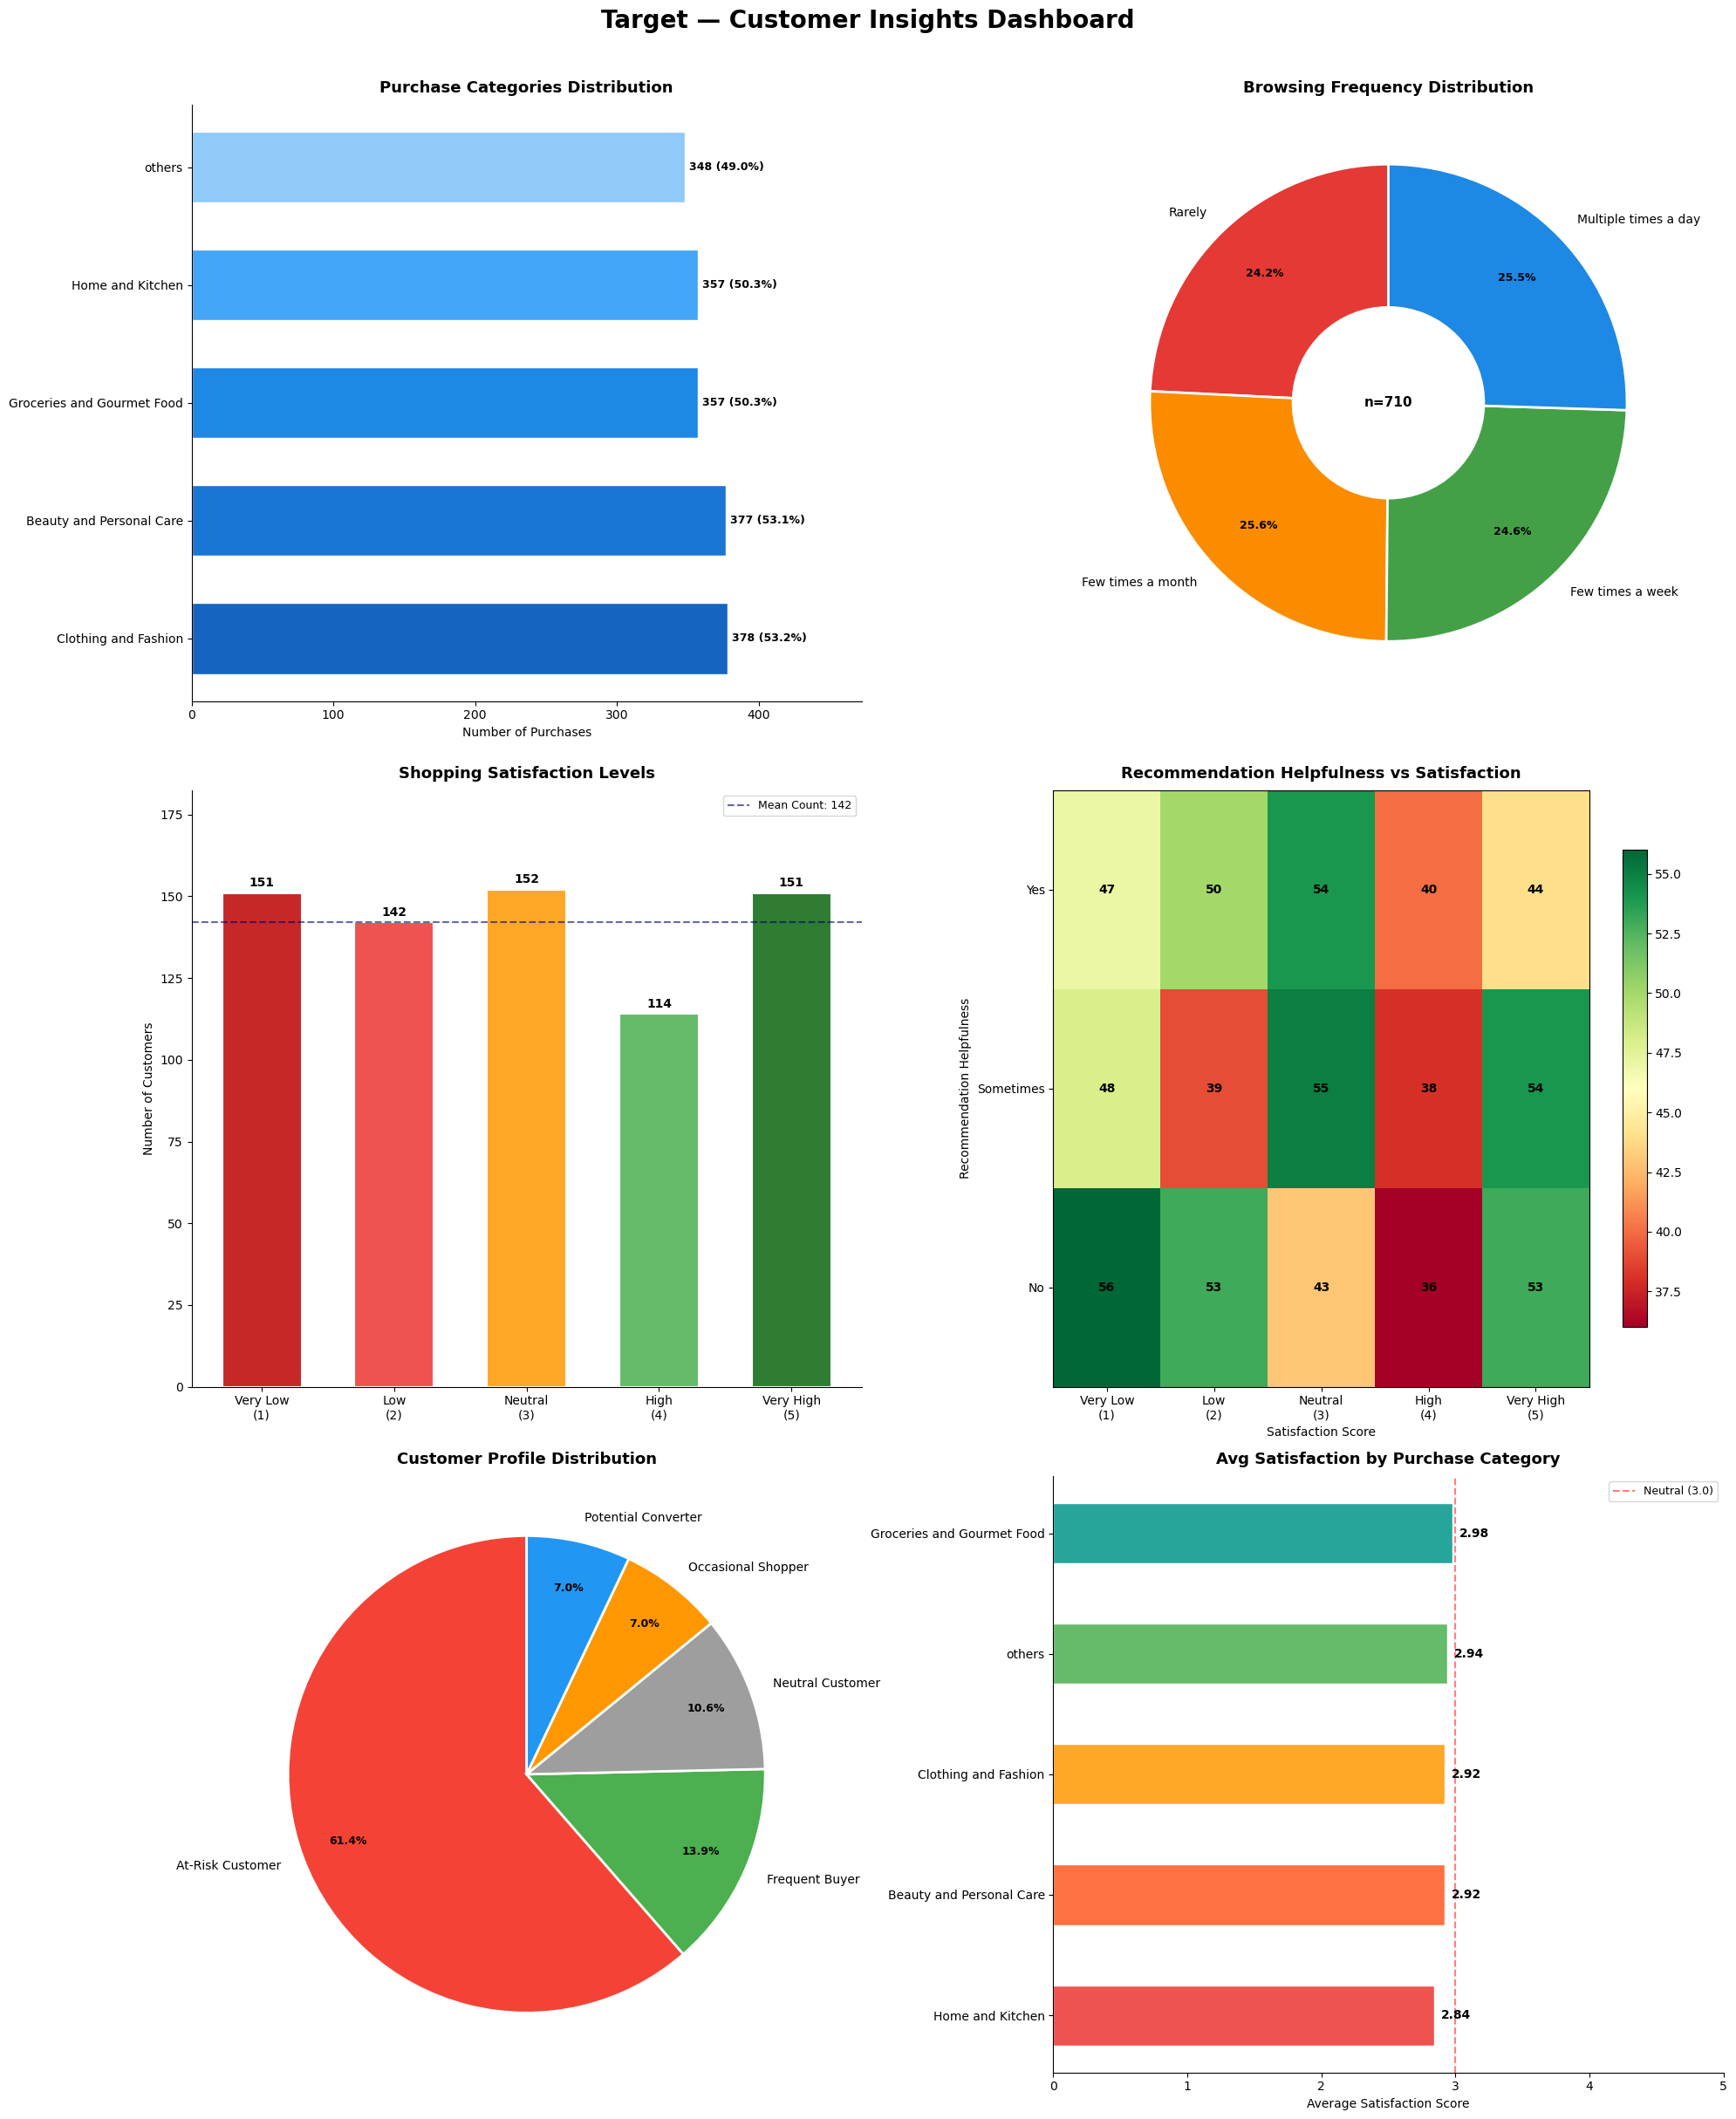

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(20, 24))
fig.suptitle('Target — Customer Insights Dashboard',
             fontsize=20, fontweight='bold', y=1.01)

# ============================================================
# PLOT 1 - Purchase Categories (Horizontal Bar)
# ============================================================
ax1 = fig.add_subplot(3, 2, 1)

categories_exploded = df['Purchase_Categories'].str.split(';').explode().str.strip()
cat_counts = categories_exploded.value_counts()
colors_cat = ['#1565C0','#1976D2','#1E88E5','#42A5F5','#90CAF9']

bars = ax1.barh(cat_counts.index, cat_counts.values,
                color=colors_cat, edgecolor='white', height=0.6)
ax1.set_title('Purchase Categories Distribution',
              fontweight='bold', fontsize=13, pad=10)
ax1.set_xlabel('Number of Purchases')
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(df)*100:.1f}%)',
             va='center', fontsize=9, fontweight='bold')
ax1.set_xlim(0, max(cat_counts.values) * 1.25)
ax1.spines[['top','right']].set_visible(False)

# ============================================================
# PLOT 2 - Browsing Frequency Distribution (Donut Chart)
# ============================================================
ax2 = fig.add_subplot(3, 2, 2)

browse_order  = ['Rarely','Few times a month',
                 'Few times a week','Multiple times a day']
browse_counts = df['Browsing_Frequency'].value_counts().reindex(browse_order)
colors_browse = ['#E53935','#FB8C00','#43A047','#1E88E5']
wedges, texts, autotexts = ax2.pie(
    browse_counts.values,
    labels=browse_order,
    autopct='%1.1f%%',
    colors=colors_browse,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2,'width':0.6}
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax2.set_title('Browsing Frequency Distribution',
              fontweight='bold', fontsize=13, pad=10)
centre = plt.Circle((0,0), 0.40, fc='white')
ax2.add_patch(centre)
ax2.text(0, 0, f'n={len(df)}', ha='center',
         va='center', fontsize=11, fontweight='bold')

# ============================================================
# PLOT 3 - Satisfaction Levels (Styled Bar Chart)
# ============================================================
ax3 = fig.add_subplot(3, 2, 3)

sat_counts = df['Shopping_Satisfaction'].value_counts().sort_index()
sat_labels  = ['Very Low\n(1)','Low\n(2)',
               'Neutral\n(3)','High\n(4)','Very High\n(5)']
colors_sat  = ['#C62828','#EF5350','#FFA726','#66BB6A','#2E7D32']

bars3 = ax3.bar(sat_labels, sat_counts.values,
                color=colors_sat, edgecolor='white',
                linewidth=1.5, width=0.6)
ax3.set_title('Shopping Satisfaction Levels',
              fontweight='bold', fontsize=13, pad=10)
ax3.set_ylabel('Number of Customers')
ax3.set_ylim(0, max(sat_counts.values) * 1.2)
ax3.spines[['top','right']].set_visible(False)
ax3.axhline(y=sat_counts.mean(), color='navy',
            linestyle='--', alpha=0.6,
            label=f'Mean Count: {sat_counts.mean():.0f}')
ax3.legend(fontsize=9)
for bar, val in zip(bars3, sat_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2, str(val),
             ha='center', fontweight='bold', fontsize=10)

# ============================================================
# PLOT 4 - Recommendation Helpfulness vs Satisfaction (Heatmap)
# ============================================================
ax4 = fig.add_subplot(3, 2, 4)

heat_data = df.groupby(['Recommendation_Helpfulness',
                         'Shopping_Satisfaction']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(['Yes','Sometimes','No'])

im = ax4.imshow(heat_data.values, cmap='RdYlGn', aspect='auto')
ax4.set_xticks(range(5))
ax4.set_xticklabels(['Very Low\n(1)','Low\n(2)','Neutral\n(3)',
                      'High\n(4)','Very High\n(5)'])
ax4.set_yticks(range(3))
ax4.set_yticklabels(['Yes','Sometimes','No'])
ax4.set_title('Recommendation Helpfulness vs Satisfaction',
              fontweight='bold', fontsize=13, pad=10)
ax4.set_xlabel('Satisfaction Score')
ax4.set_ylabel('Recommendation Helpfulness')
plt.colorbar(im, ax=ax4, shrink=0.8)
for i in range(3):
    for j in range(5):
        ax4.text(j, i, str(heat_data.values[i, j]),
                 ha='center', va='center',
                 fontweight='bold', fontsize=10,
                 color='black')

# ============================================================
# PLOT 5 - Customer Profile Distribution (Pie)
# ============================================================
ax5 = fig.add_subplot(3, 2, 5)

profile_counts = df['Customer_Profile'].value_counts()
colors_profile = ['#F44336','#4CAF50','#9E9E9E','#FF9800','#2196F3']
wedges5, texts5, auto5 = ax5.pie(
    profile_counts.values,
    labels=profile_counts.index,
    autopct='%1.1f%%',
    colors=colors_profile,
    startangle=90,
    pctdistance=0.80,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for text in auto5:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax5.set_title('Customer Profile Distribution',
              fontweight='bold', fontsize=13, pad=10)

# ============================================================
# PLOT 6 - Avg Satisfaction by Purchase Category (Bar)
# ============================================================
ax6 = fig.add_subplot(3, 2, 6)

df_exploded = df.copy()
df_exploded['Category'] = df['Purchase_Categories'].str.split(';')
df_exploded = df_exploded.explode('Category')
df_exploded['Category'] = df_exploded['Category'].str.strip()

cat_sat = df_exploded.groupby('Category')['Shopping_Satisfaction'].mean().round(2)
cat_sat = cat_sat.sort_values(ascending=True)
colors_cs = ['#EF5350','#FF7043','#FFA726','#66BB6A','#26A69A']

bars6 = ax6.barh(cat_sat.index, cat_sat.values,
                  color=colors_cs, edgecolor='white', height=0.5)
ax6.set_title('Avg Satisfaction by Purchase Category',
              fontweight='bold', fontsize=13, pad=10)
ax6.set_xlabel('Average Satisfaction Score')
ax6.set_xlim(0, 5)
ax6.axvline(x=3, color='red', linestyle='--',
            alpha=0.5, label='Neutral (3.0)')
ax6.legend(fontsize=9)
ax6.spines[['top','right']].set_visible(False)
for bar, val in zip(bars6, cat_sat.values):
    ax6.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('target_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

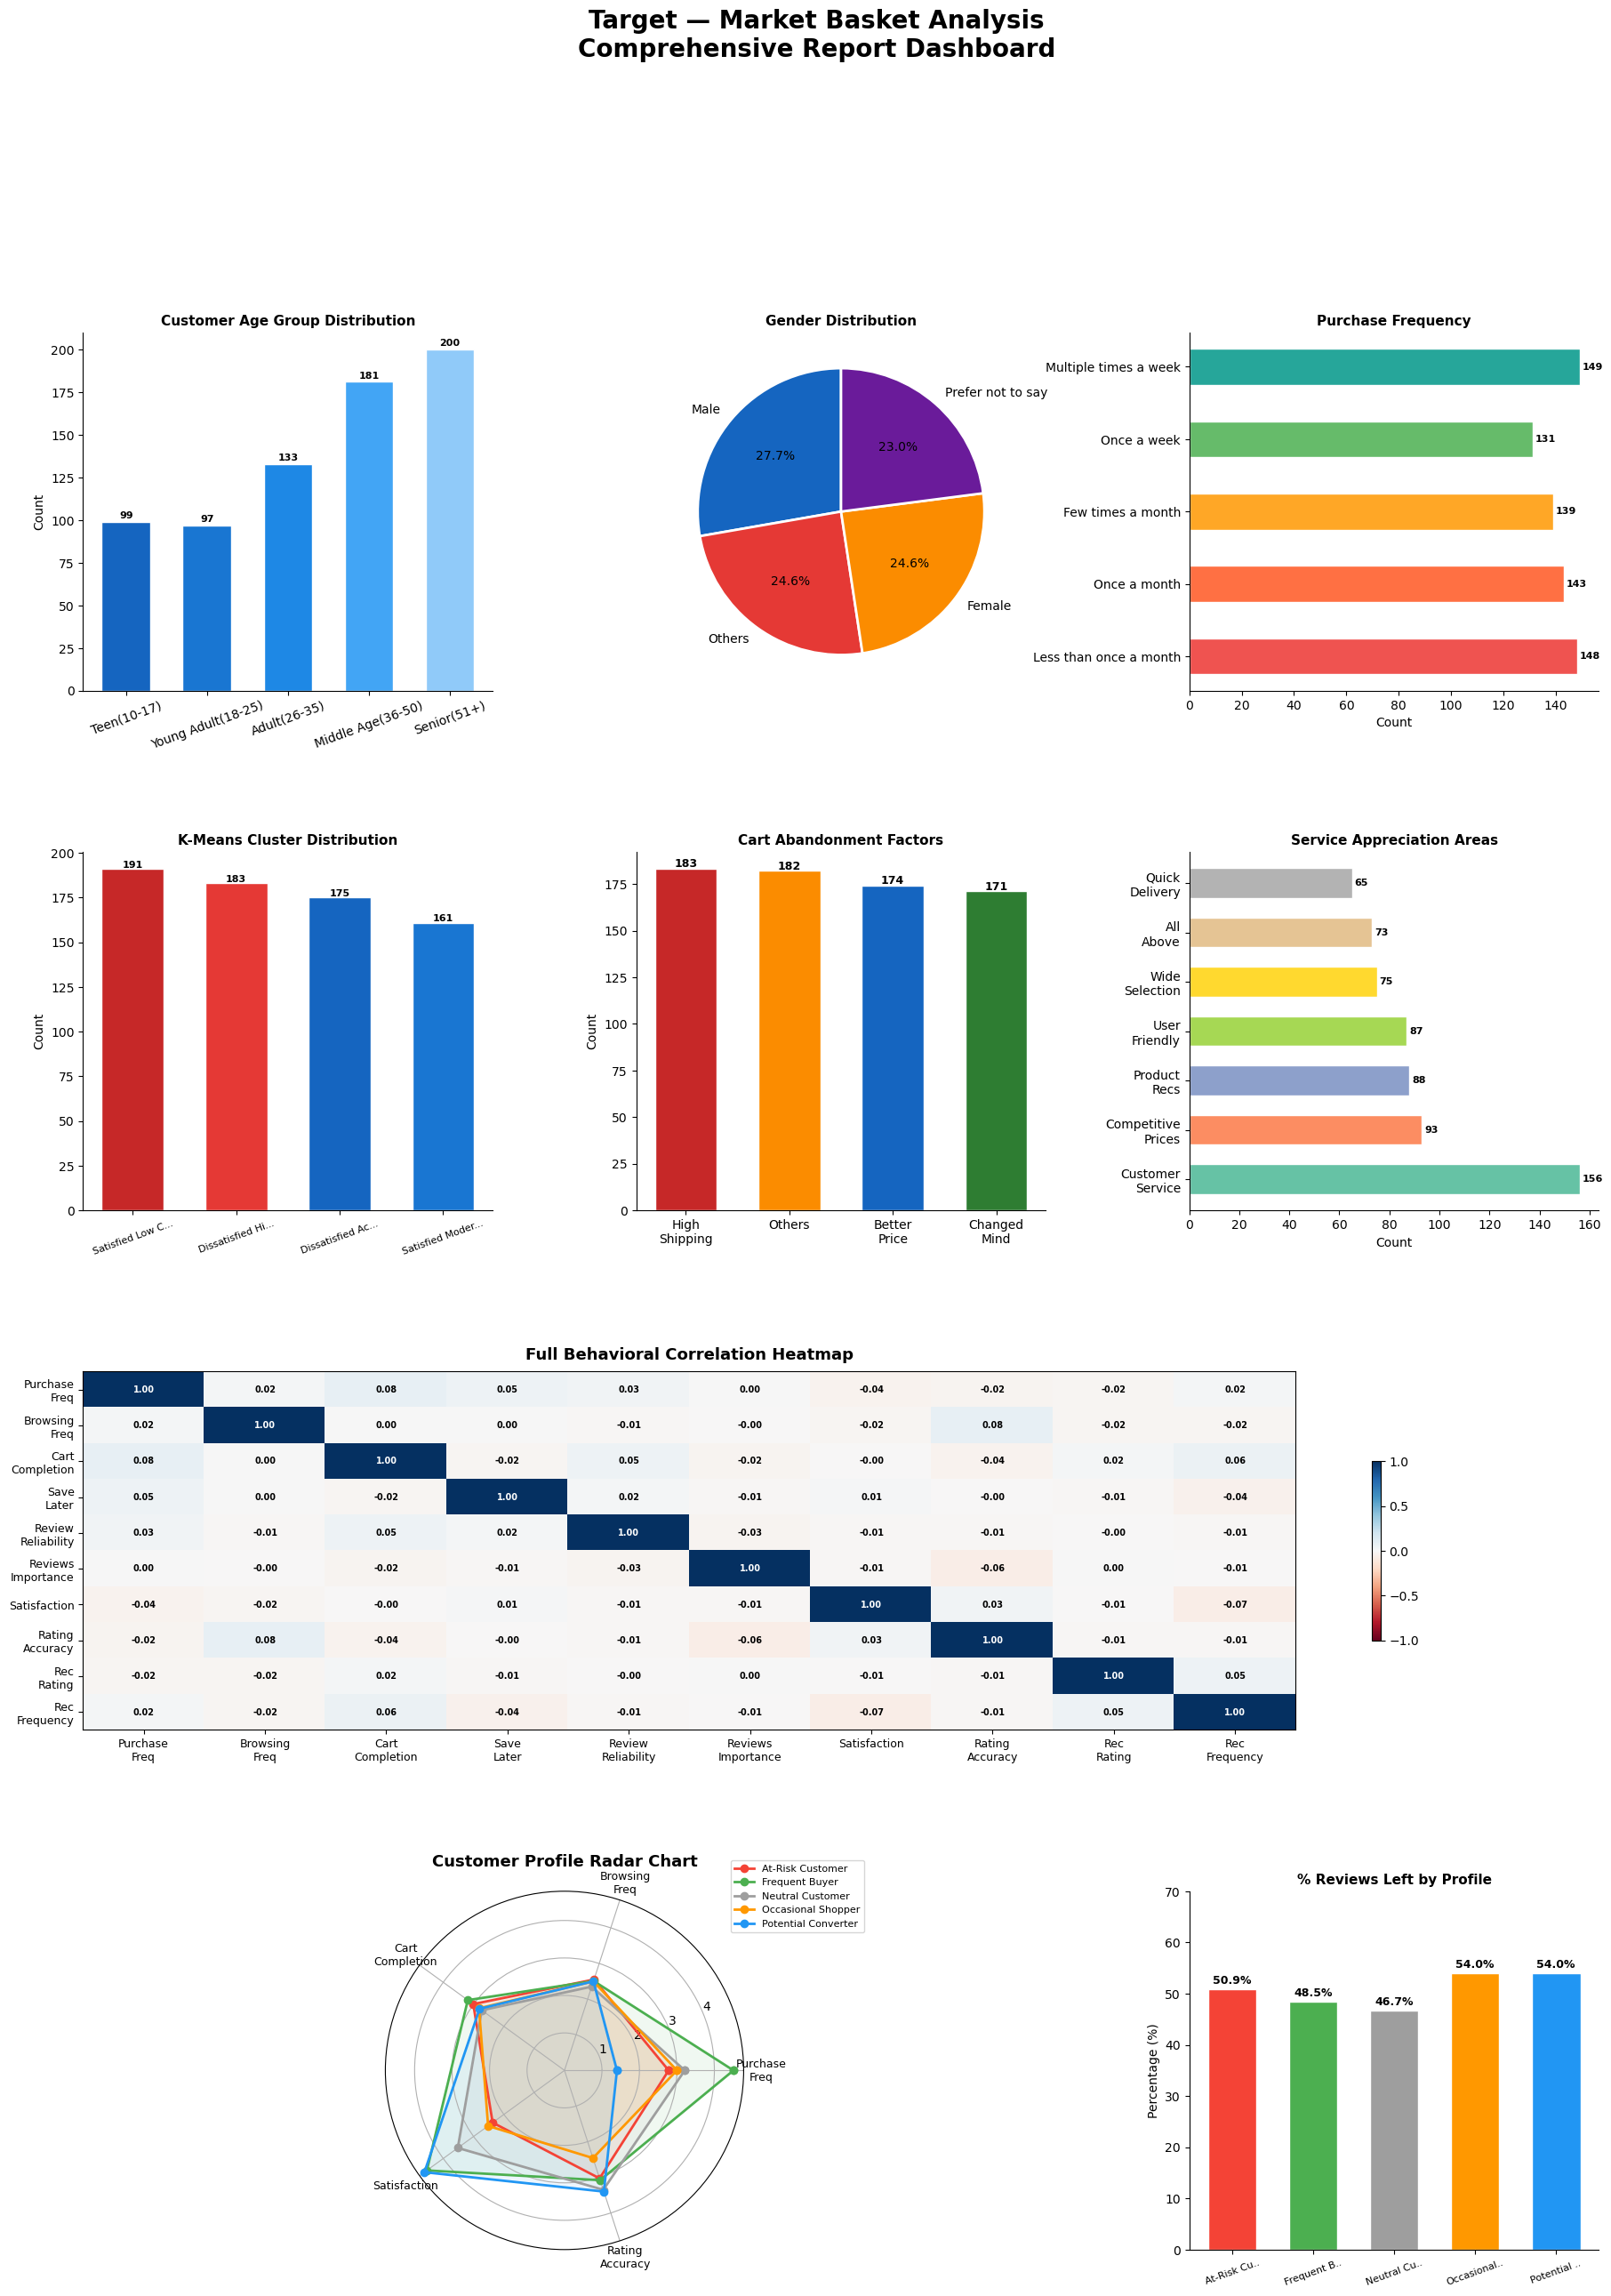

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(22, 28))
fig.suptitle('Target — Market Basket Analysis\nComprehensive Report Dashboard',
             fontsize=20, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(4, 3, figure=fig,
                        hspace=0.45, wspace=0.35)

# ============================================================
# PLOT 1 - Age Group Distribution
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
age_counts  = df['Age_Group'].value_counts().sort_index()
colors_age  = ['#1565C0','#1976D2','#1E88E5','#42A5F5','#90CAF9']
bars1 = ax1.bar(age_counts.index, age_counts.values,
                color=colors_age, edgecolor='white', width=0.6)
ax1.set_title('Customer Age Group Distribution',
              fontweight='bold', fontsize=11)
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=20)
ax1.spines[['top','right']].set_visible(False)
for bar, val in zip(bars1, age_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2, str(val),
             ha='center', fontsize=8, fontweight='bold')

# ============================================================
# PLOT 2 - Gender Distribution
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])
gender_counts = df['Gender'].value_counts()
colors_gen    = ['#1565C0','#E53935','#FB8C00','#6A1B9A']
ax2.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        colors=colors_gen,
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Gender Distribution',
              fontweight='bold', fontsize=11)

# ============================================================
# PLOT 3 - Purchase Frequency Distribution
# ============================================================
ax3 = fig.add_subplot(gs[0, 2])
freq_order  = ['Less than once a month','Once a month',
               'Few times a month','Once a week',
               'Multiple times a week']
freq_counts = df['Purchase_Frequency'].value_counts().reindex(freq_order)
colors_freq = ['#EF5350','#FF7043','#FFA726','#66BB6A','#26A69A']
bars3 = ax3.barh(freq_order, freq_counts.values,
                  color=colors_freq, edgecolor='white', height=0.5)
ax3.set_title('Purchase Frequency',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Count')
ax3.spines[['top','right']].set_visible(False)
for bar, val in zip(bars3, freq_counts.values):
    ax3.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8, fontweight='bold')

# ============================================================
# PLOT 4 - K-Means Cluster Distribution
# ============================================================
ax4 = fig.add_subplot(gs[1, 0])
cluster_dist = df['Cluster_Label'].value_counts()
colors_cl    = ['#C62828','#E53935','#1565C0','#1976D2']
bars4 = ax4.bar(range(len(cluster_dist)),
                cluster_dist.values,
                color=colors_cl, edgecolor='white', width=0.6)
ax4.set_title('K-Means Cluster Distribution',
              fontweight='bold', fontsize=11)
ax4.set_ylabel('Count')
ax4.set_xticks(range(len(cluster_dist)))
ax4.set_xticklabels([c[:15] + '...' for c in cluster_dist.index],
                     rotation=20, fontsize=8)
ax4.spines[['top','right']].set_visible(False)
for bar, val in zip(bars4, cluster_dist.values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha='center', fontsize=8, fontweight='bold')

# ============================================================
# PLOT 5 - Cart Abandonment Factors
# ============================================================
ax5 = fig.add_subplot(gs[1, 1])
abandon      = df['Cart_Abandonment_Factors'].value_counts()
short_labels = ['High\nShipping','Others',
                'Better\nPrice','Changed\nMind']
colors_ab    = ['#C62828','#FB8C00','#1565C0','#2E7D32']
bars5 = ax5.bar(short_labels, abandon.values,
                color=colors_ab, edgecolor='white', width=0.6)
ax5.set_title('Cart Abandonment Factors',
              fontweight='bold', fontsize=11)
ax5.set_ylabel('Count')
ax5.spines[['top','right']].set_visible(False)
for bar, val in zip(bars5, abandon.values):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha='center', fontsize=9, fontweight='bold')

# ============================================================
# PLOT 6 - Service Appreciation Distribution
# ============================================================
ax6 = fig.add_subplot(gs[1, 2])
service = df[df['Service_Appreciation'] != 'Not Specified'][
    'Service_Appreciation'].value_counts()
short_svc = ['Customer\nService','Competitive\nPrices',
             'Product\nRecs','User\nFriendly',
             'Wide\nSelection','All\nAbove','Quick\nDelivery']
colors_svc = plt.cm.Set2(np.linspace(0, 1, len(service)))
bars6 = ax6.barh(short_svc, service.values,
                  color=colors_svc, edgecolor='white', height=0.6)
ax6.set_title('Service Appreciation Areas',
              fontweight='bold', fontsize=11)
ax6.set_xlabel('Count')
ax6.spines[['top','right']].set_visible(False)
for bar, val in zip(bars6, service.values):
    ax6.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8, fontweight='bold')

# ============================================================
# PLOT 7 - Full Correlation Heatmap
# ============================================================
ax7 = fig.add_subplot(gs[2, :])
corr_cols = ['Purchase_Frequency_Encoded',
             'Browsing_Frequency_Encoded',
             'Cart_Completion_Encoded',
             'Saveforlater_Encoded',
             'Review_Reliability_Encoded',
             'Customer_Reviews_Importance',
             'Shopping_Satisfaction',
             'Rating_Accuracy',
             'Personalized_Recommendation_Rating',
             'Personalized_Recommendation_Frequency']

corr_labels = ['Purchase\nFreq','Browsing\nFreq',
               'Cart\nCompletion','Save\nLater',
               'Review\nReliability','Reviews\nImportance',
               'Satisfaction','Rating\nAccuracy',
               'Rec\nRating','Rec\nFrequency']

corr_data = df[corr_cols].astype(float).corr()
im7 = ax7.imshow(corr_data.values, cmap='RdBu',
                  vmin=-1, vmax=1, aspect='auto')
ax7.set_xticks(range(len(corr_labels)))
ax7.set_yticks(range(len(corr_labels)))
ax7.set_xticklabels(corr_labels, fontsize=9)
ax7.set_yticklabels(corr_labels, fontsize=9)
ax7.set_title('Full Behavioral Correlation Heatmap',
              fontweight='bold', fontsize=13, pad=10)
plt.colorbar(im7, ax=ax7, shrink=0.5)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_data.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax7.text(j, i, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=7, fontweight='bold', color=color)

# ============================================================
# PLOT 8 - Segment Profile Radar (Spider) Chart
# ============================================================
ax8 = fig.add_subplot(gs[3, :2], polar=True)

metrics      = ['Avg_Purchase_Freq','Avg_Browsing',
                'Avg_Cart_Completion','Avg_Satisfaction',
                'Avg_Rating_Accuracy']
metric_names = ['Purchase\nFreq','Browsing\nFreq',
                'Cart\nCompletion','Satisfaction',
                'Rating\nAccuracy']

profile_radar = df.groupby('Customer_Profile').agg(
    Avg_Purchase_Freq   = ('Purchase_Frequency_Encoded','mean'),
    Avg_Browsing        = ('Browsing_Frequency_Encoded','mean'),
    Avg_Cart_Completion = ('Cart_Completion_Encoded','mean'),
    Avg_Satisfaction    = ('Shopping_Satisfaction','mean'),
    Avg_Rating_Accuracy = ('Rating_Accuracy','mean')
).round(2)

N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_radar = ['#F44336','#4CAF50','#9E9E9E','#FF9800','#2196F3']
for idx, (profile, row) in enumerate(profile_radar.iterrows()):
    values  = row[metrics].tolist()
    values += values[:1]
    ax8.plot(angles, values, 'o-', linewidth=2,
             color=colors_radar[idx], label=profile)
    ax8.fill(angles, values, alpha=0.08,
             color=colors_radar[idx])

ax8.set_xticks(angles[:-1])
ax8.set_xticklabels(metric_names, fontsize=9)
ax8.set_title('Customer Profile Radar Chart',
              fontweight='bold', fontsize=13, pad=20)
ax8.legend(loc='upper right',
           bbox_to_anchor=(1.35, 1.1), fontsize=8)

# ============================================================
# PLOT 9 - Review Left by Profile
# ============================================================
ax9 = fig.add_subplot(gs[3, 2])
review_profile = df.groupby('Customer_Profile').apply(
    lambda x: (x['Review_Left'] == 'Yes').sum() / len(x) * 100
).round(1)
colors_rev = ['#F44336','#4CAF50','#9E9E9E','#FF9800','#2196F3']
bars9 = ax9.bar(range(len(review_profile)),
                review_profile.values,
                color=colors_rev, edgecolor='white', width=0.6)
ax9.set_title('% Reviews Left by Profile',
              fontweight='bold', fontsize=11)
ax9.set_ylabel('Percentage (%)')
ax9.set_ylim(0, 70)
ax9.set_xticks(range(len(review_profile)))
ax9.set_xticklabels([p[:10] + '..' for p in review_profile.index],
                     rotation=20, fontsize=8)
ax9.spines[['top','right']].set_visible(False)
for bar, val in zip(bars9, review_profile.values):
    ax9.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f'{val}%',
             ha='center', fontsize=9, fontweight='bold')

plt.savefig('target_final_report.png', dpi=150, bbox_inches='tight')
plt.show()

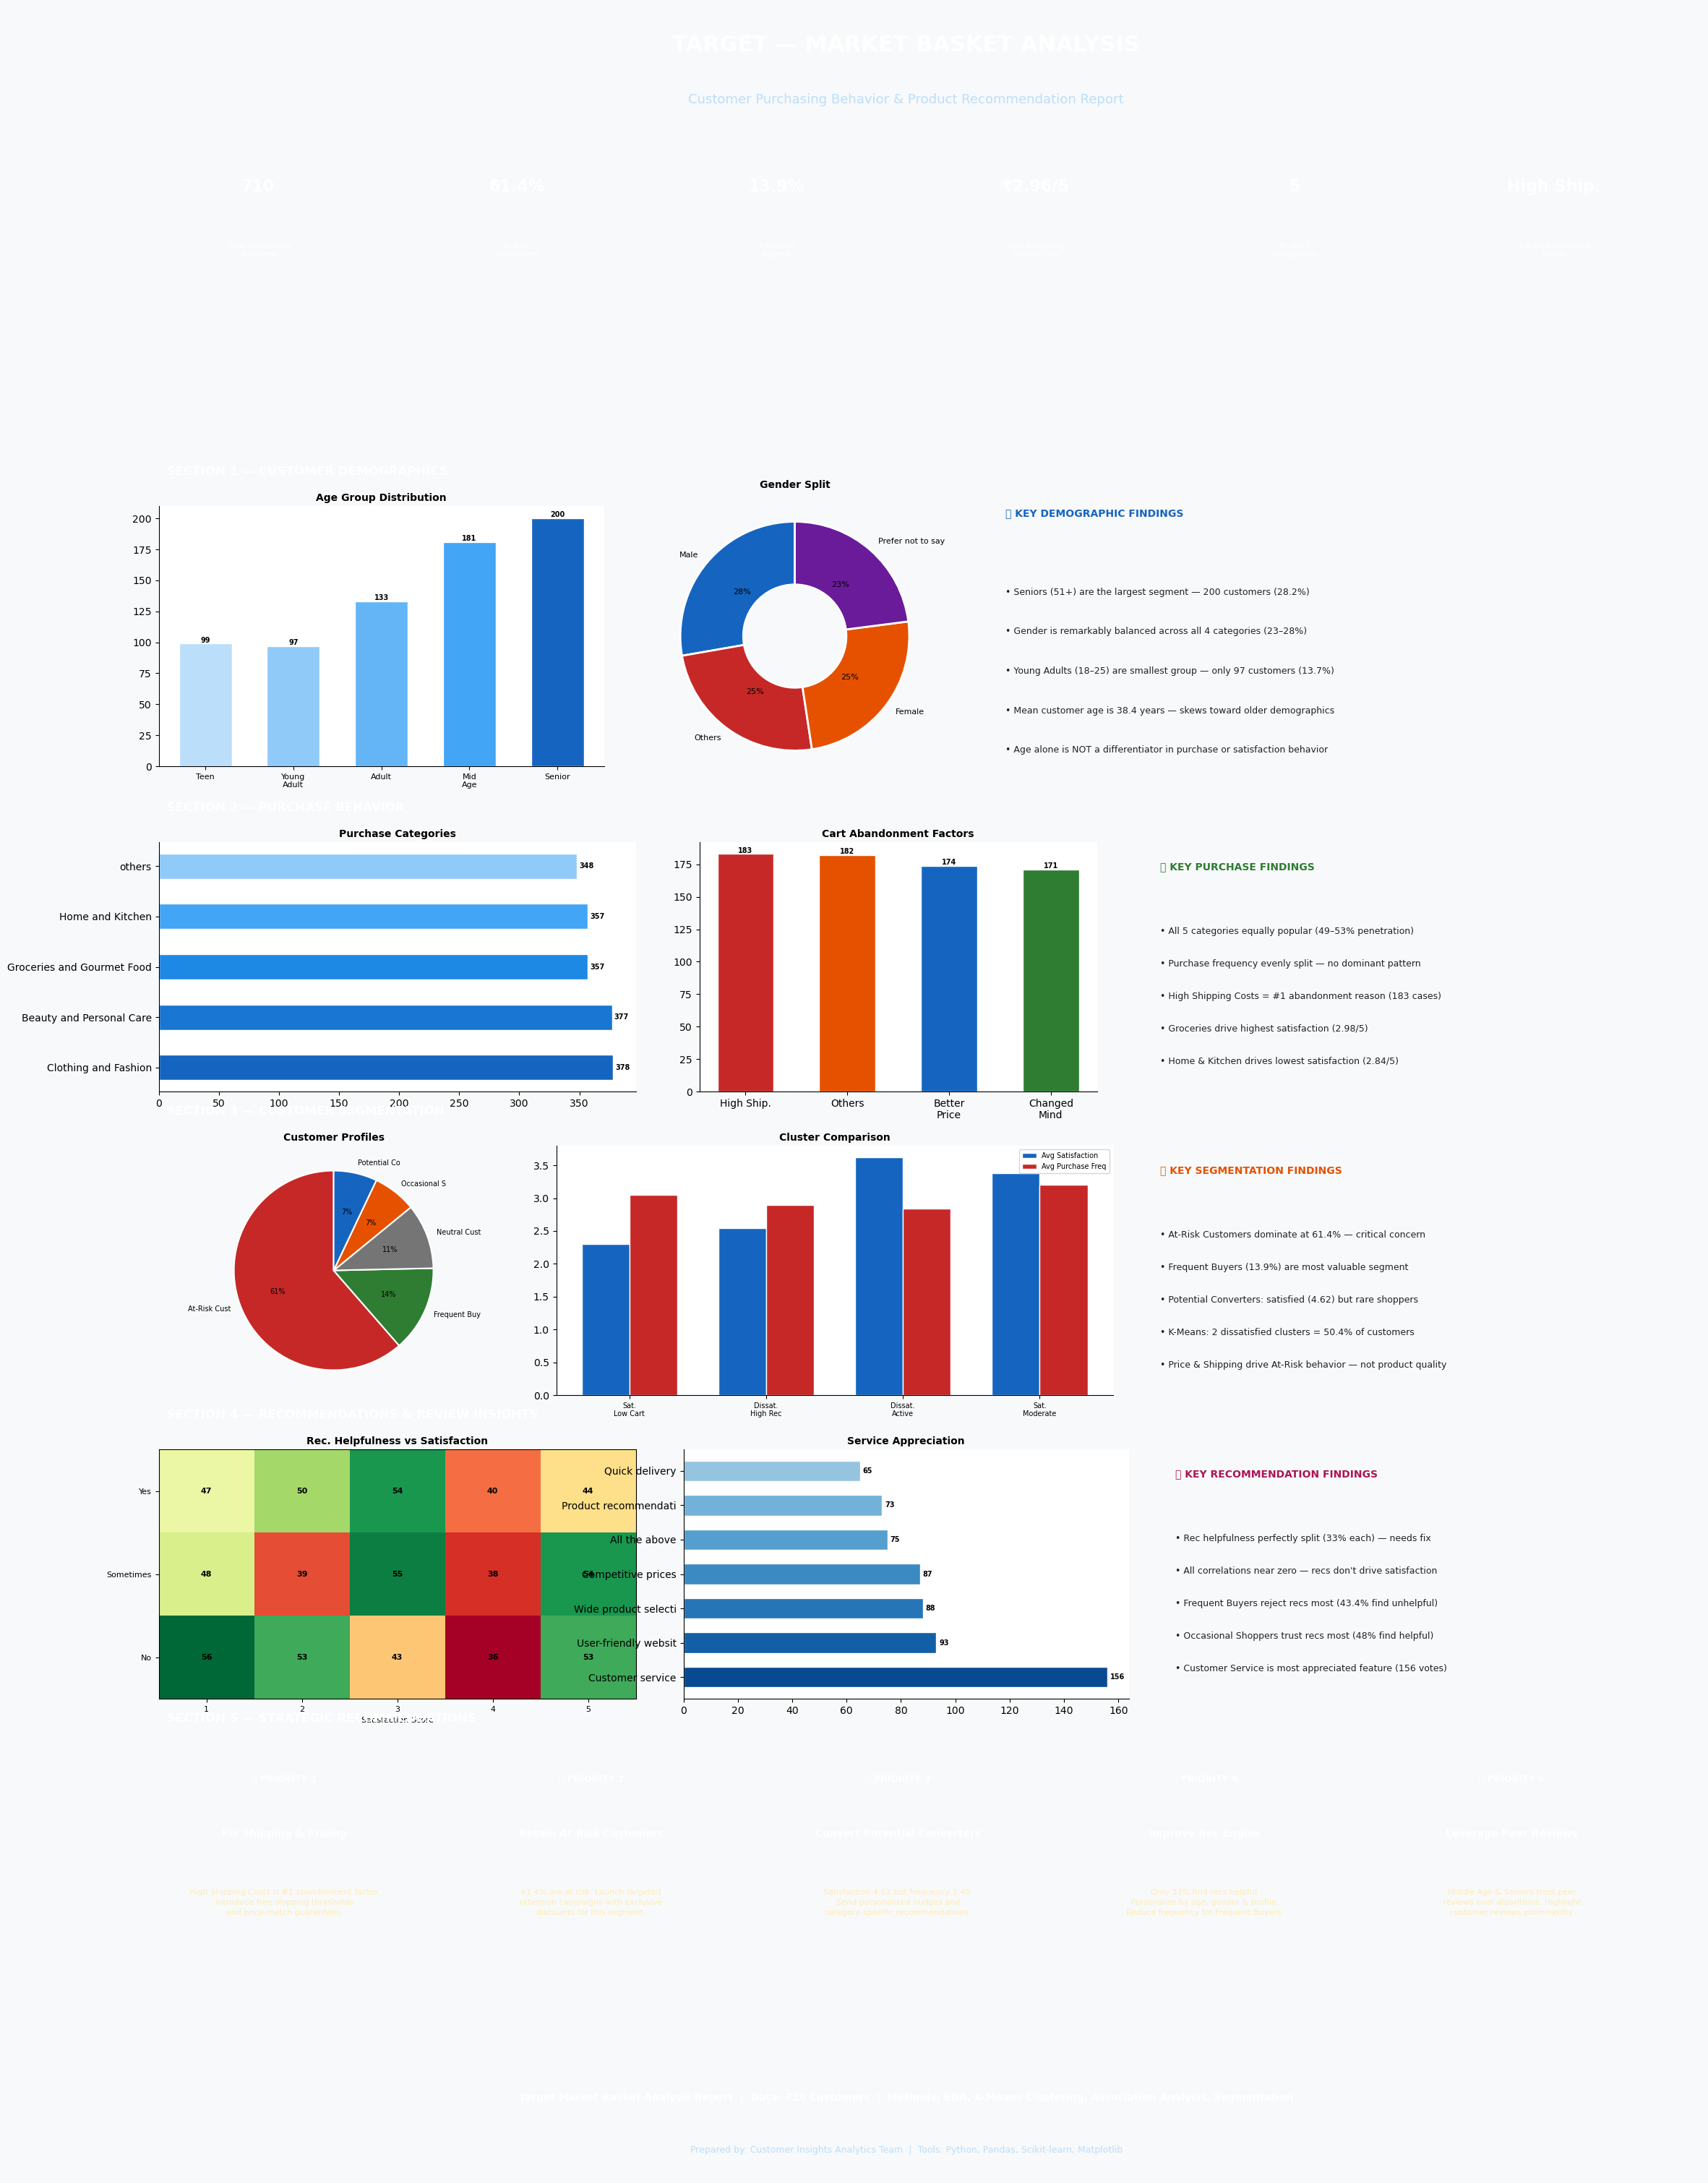

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig = plt.figure(figsize=(22, 30))
fig.patch.set_facecolor('#F8F9FA')

# ============================================================
# TITLE SECTION
# ============================================================
ax_title = fig.add_axes([0, 0.95, 1, 0.05])
ax_title.set_facecolor('#1565C0')
ax_title.text(0.5, 0.65,
              'TARGET — MARKET BASKET ANALYSIS',
              ha='center', va='center',
              fontsize=22, fontweight='bold', color='white')
ax_title.text(0.5, 0.15,
              'Customer Purchasing Behavior & Product Recommendation Report',
              ha='center', va='center',
              fontsize=13, color='#BBDEFB')
ax_title.axis('off')

# ============================================================
# KPI CARDS ROW
# ============================================================
kpi_data = [
    ('710',        'Total Customers\nAnalyzed',    '#1565C0'),
    ('61.4%',      'At-Risk\nCustomers',           '#C62828'),
    ('13.9%',      'Frequent\nBuyers',             '#2E7D32'),
    ('₹2.96/5',    'Avg Shopping\nSatisfaction',   '#E65100'),
    ('5',          'Product\nCategories',          '#6A1B9A'),
    ('High Ship.', 'Top Abandonment\nFactor',      '#AD1457'),
]

for i, (val, label, color) in enumerate(kpi_data):
    ax = fig.add_axes([0.02 + i*0.163, 0.875, 0.145, 0.065])
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, val, ha='center', va='center',
            fontsize=16, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=8, color='#FFFFFF',
            transform=ax.transAxes)
    ax.axis('off')

# ============================================================
# SECTION 1 - Demographics Summary
# ============================================================
ax_dem = fig.add_axes([0.02, 0.78, 0.96, 0.02])
ax_dem.set_facecolor('#1976D2')
ax_dem.text(0.01, 0.3, '  SECTION 1 — CUSTOMER DEMOGRAPHICS',
            va='center', fontsize=12,
            fontweight='bold', color='white')
ax_dem.axis('off')

# Age Group Bar
ax1 = fig.add_axes([0.03, 0.65, 0.28, 0.12])
ax1.set_facecolor('white')
age_counts  = df['Age_Group'].value_counts().sort_index()
colors_age  = ['#BBDEFB','#90CAF9','#64B5F6','#42A5F5','#1565C0']
bars = ax1.bar(range(len(age_counts)), age_counts.values,
               color=colors_age, edgecolor='white', width=0.6)
ax1.set_title('Age Group Distribution',
              fontweight='bold', fontsize=10, pad=5)
ax1.set_xticks(range(len(age_counts)))
ax1.set_xticklabels(['Teen','Young\nAdult','Adult',
                      'Mid\nAge','Senior'], fontsize=8)
ax1.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, age_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha='center', fontsize=7, fontweight='bold')

# Gender Donut
ax2 = fig.add_axes([0.34, 0.64, 0.18, 0.14])
ax2.set_facecolor('white')
gender_counts = df['Gender'].value_counts()
colors_gen    = ['#1565C0','#C62828','#E65100','#6A1B9A']
ax2.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.0f%%',
        colors=colors_gen,
        startangle=90,
        textprops={'fontsize': 8},
        wedgeprops={'edgecolor':'white',
                    'linewidth':2,'width':0.55})
ax2.set_title('Gender Split',
              fontweight='bold', fontsize=10, pad=5)

# Key Demographic Findings Text Box
ax3 = fig.add_axes([0.55, 0.64, 0.42, 0.14])
ax3.set_facecolor('#E3F2FD')
findings_dem = [
    '📊 KEY DEMOGRAPHIC FINDINGS',
    '',
    '• Seniors (51+) are the largest segment — 200 customers (28.2%)',
    '• Gender is remarkably balanced across all 4 categories (23–28%)',
    '• Young Adults (18–25) are smallest group — only 97 customers (13.7%)',
    '• Mean customer age is 38.4 years — skews toward older demographics',
    '• Age alone is NOT a differentiator in purchase or satisfaction behavior',
]
for j, line in enumerate(findings_dem):
    weight = 'bold' if j == 0 else 'normal'
    size   = 10 if j == 0 else 9
    ax3.text(0.03, 0.92 - j*0.13, line,
             transform=ax3.transAxes,
             fontsize=size, fontweight=weight,
             color='#1565C0' if j == 0 else '#212121',
             va='top')
ax3.axis('off')

# ============================================================
# SECTION 2 - Purchase Behavior
# ============================================================
ax_purch = fig.add_axes([0.02, 0.625, 0.96, 0.02])
ax_purch.set_facecolor('#1976D2')
ax_purch.text(0.01, 0.3, '  SECTION 2 — PURCHASE BEHAVIOR',
              va='center', fontsize=12,
              fontweight='bold', color='white')
ax_purch.axis('off')

# Categories Bar
ax4 = fig.add_axes([0.03, 0.50, 0.30, 0.115])
ax4.set_facecolor('white')
cat_counts  = df['Purchase_Categories'].str.split(';').explode(
    ).str.strip().value_counts()
colors_cat  = ['#1565C0','#1976D2','#1E88E5','#42A5F5','#90CAF9']
bars4 = ax4.barh(cat_counts.index, cat_counts.values,
                  color=colors_cat, edgecolor='white', height=0.5)
ax4.set_title('Purchase Categories',
              fontweight='bold', fontsize=10, pad=5)
ax4.spines[['top','right']].set_visible(False)
for bar, val in zip(bars4, cat_counts.values):
    ax4.text(bar.get_width() + 2,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=7, fontweight='bold')

# Cart Abandonment
ax5 = fig.add_axes([0.37, 0.50, 0.25, 0.115])
ax5.set_facecolor('white')
abandon      = df['Cart_Abandonment_Factors'].value_counts()
short_labels = ['High Ship.','Others','Better\nPrice','Changed\nMind']
colors_ab    = ['#C62828','#E65100','#1565C0','#2E7D32']
bars5 = ax5.bar(short_labels, abandon.values,
                color=colors_ab, edgecolor='white', width=0.55)
ax5.set_title('Cart Abandonment Factors',
              fontweight='bold', fontsize=10, pad=5)
ax5.spines[['top','right']].set_visible(False)
for bar, val in zip(bars5, abandon.values):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha='center', fontsize=7, fontweight='bold')

# Purchase Findings
ax6 = fig.add_axes([0.65, 0.50, 0.32, 0.115])
ax6.set_facecolor('#E8F5E9')
findings_pur = [
    '🛒 KEY PURCHASE FINDINGS',
    '',
    '• All 5 categories equally popular (49–53% penetration)',
    '• Purchase frequency evenly split — no dominant pattern',
    '• High Shipping Costs = #1 abandonment reason (183 cases)',
    '• Groceries drive highest satisfaction (2.98/5)',
    '• Home & Kitchen drives lowest satisfaction (2.84/5)',
]
for j, line in enumerate(findings_pur):
    weight = 'bold' if j == 0 else 'normal'
    size   = 10 if j == 0 else 9
    ax6.text(0.03, 0.92 - j*0.13, line,
             transform=ax6.transAxes,
             fontsize=size, fontweight=weight,
             color='#2E7D32' if j == 0 else '#212121',
             va='top')
ax6.axis('off')

# ============================================================
# SECTION 3 - Customer Segmentation
# ============================================================
ax_seg = fig.add_axes([0.02, 0.485, 0.96, 0.02])
ax_seg.set_facecolor('#1976D2')
ax_seg.text(0.01, 0.3, '  SECTION 3 — CUSTOMER SEGMENTATION',
            va='center', fontsize=12,
            fontweight='bold', color='white')
ax_seg.axis('off')

# Profile Distribution
ax7 = fig.add_axes([0.03, 0.36, 0.22, 0.115])
ax7.set_facecolor('white')
profile_counts = df['Customer_Profile'].value_counts()
colors_prof    = ['#C62828','#2E7D32','#757575','#E65100','#1565C0']
ax7.pie(profile_counts.values,
        labels=[p[:12] for p in profile_counts.index],
        autopct='%1.0f%%',
        colors=colors_prof,
        startangle=90,
        textprops={'fontsize': 7},
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax7.set_title('Customer Profiles',
              fontweight='bold', fontsize=10, pad=5)

# Cluster Metrics Comparison
ax8 = fig.add_axes([0.28, 0.36, 0.35, 0.115])
ax8.set_facecolor('white')
cluster_sat = df.groupby('Cluster_Label')['Shopping_Satisfaction'].mean()
cluster_freq = df.groupby('Cluster_Label')[
    'Purchase_Frequency_Encoded'].mean()
short_cl = ['Sat.\nLow Cart','Dissat.\nHigh Rec',
            'Dissat.\nActive','Sat.\nModerate']
x      = np.arange(len(short_cl))
width  = 0.35
bars8a = ax8.bar(x - width/2, cluster_sat.values,
                  width, label='Avg Satisfaction',
                  color='#1565C0', edgecolor='white')
bars8b = ax8.bar(x + width/2, cluster_freq.values,
                  width, label='Avg Purchase Freq',
                  color='#C62828', edgecolor='white')
ax8.set_title('Cluster Comparison',
              fontweight='bold', fontsize=10, pad=5)
ax8.set_xticks(x)
ax8.set_xticklabels(short_cl, fontsize=7)
ax8.legend(fontsize=7)
ax8.spines[['top','right']].set_visible(False)

# Segmentation Findings
ax9 = fig.add_axes([0.65, 0.36, 0.32, 0.115])
ax9.set_facecolor('#FFF3E0')
findings_seg = [
    '👥 KEY SEGMENTATION FINDINGS',
    '',
    '• At-Risk Customers dominate at 61.4% — critical concern',
    '• Frequent Buyers (13.9%) are most valuable segment',
    '• Potential Converters: satisfied (4.62) but rare shoppers',
    '• K-Means: 2 dissatisfied clusters = 50.4% of customers',
    '• Price & Shipping drive At-Risk behavior — not product quality',
]
for j, line in enumerate(findings_seg):
    weight = 'bold' if j == 0 else 'normal'
    size   = 10 if j == 0 else 9
    ax9.text(0.03, 0.92 - j*0.13, line,
             transform=ax9.transAxes,
             fontsize=size, fontweight=weight,
             color='#E65100' if j == 0 else '#212121',
             va='top')
ax9.axis('off')

# ============================================================
# SECTION 4 - Recommendations & Insights
# ============================================================
ax_rec = fig.add_axes([0.02, 0.345, 0.96, 0.02])
ax_rec.set_facecolor('#1976D2')
ax_rec.text(0.01, 0.3,
            '  SECTION 4 — RECOMMENDATIONS & REVIEW INSIGHTS',
            va='center', fontsize=12,
            fontweight='bold', color='white')
ax_rec.axis('off')

# Rec Helpfulness vs Satisfaction Heatmap
ax10 = fig.add_axes([0.03, 0.22, 0.30, 0.115])
ax10.set_facecolor('white')
heat_data = df.groupby(['Recommendation_Helpfulness',
                         'Shopping_Satisfaction']).size().unstack(
                             fill_value=0)
heat_data = heat_data.reindex(['Yes','Sometimes','No'])
im10 = ax10.imshow(heat_data.values,
                    cmap='RdYlGn', aspect='auto')
ax10.set_xticks(range(5))
ax10.set_xticklabels(['1','2','3','4','5'], fontsize=8)
ax10.set_yticks(range(3))
ax10.set_yticklabels(['Yes','Sometimes','No'], fontsize=8)
ax10.set_title('Rec. Helpfulness vs Satisfaction',
               fontweight='bold', fontsize=10, pad=5)
ax10.set_xlabel('Satisfaction Score', fontsize=8)
for i in range(3):
    for j in range(5):
        ax10.text(j, i, str(heat_data.values[i, j]),
                  ha='center', va='center',
                  fontsize=8, fontweight='bold')

# Service Appreciation
ax11 = fig.add_axes([0.36, 0.22, 0.28, 0.115])
ax11.set_facecolor('white')
service = df[df['Service_Appreciation'] != 'Not Specified'][
    'Service_Appreciation'].value_counts()
colors_svc = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(service)))[::-1]
bars11 = ax11.barh(
    [s[:20] for s in service.index],
    service.values,
    color=colors_svc, edgecolor='white', height=0.6)
ax11.set_title('Service Appreciation',
               fontweight='bold', fontsize=10, pad=5)
ax11.spines[['top','right']].set_visible(False)
for bar, val in zip(bars11, service.values):
    ax11.text(bar.get_width() + 1,
              bar.get_y() + bar.get_height()/2,
              str(val), va='center', fontsize=7,
              fontweight='bold')

# Rec Findings
ax12 = fig.add_axes([0.66, 0.22, 0.31, 0.115])
ax12.set_facecolor('#FCE4EC')
findings_rec = [
    '⭐ KEY RECOMMENDATION FINDINGS',
    '',
    '• Rec helpfulness perfectly split (33% each) — needs fix',
    '• All correlations near zero — recs don\'t drive satisfaction',
    '• Frequent Buyers reject recs most (43.4% find unhelpful)',
    '• Occasional Shoppers trust recs most (48% find helpful)',
    '• Customer Service is most appreciated feature (156 votes)',
]
for j, line in enumerate(findings_rec):
    weight = 'bold' if j == 0 else 'normal'
    size   = 10 if j == 0 else 9
    ax12.text(0.03, 0.92 - j*0.13, line,
              transform=ax12.transAxes,
              fontsize=size, fontweight=weight,
              color='#AD1457' if j == 0 else '#212121',
              va='top')
ax12.axis('off')

# ============================================================
# SECTION 5 - Strategic Recommendations
# ============================================================
ax_strat = fig.add_axes([0.02, 0.205, 0.96, 0.02])
ax_strat.set_facecolor('#1976D2')
ax_strat.text(0.01, 0.3,
              '  SECTION 5 — STRATEGIC RECOMMENDATIONS',
              va='center', fontsize=12,
              fontweight='bold', color='white')
ax_strat.axis('off')

strategies = [
    ('#C62828', '🔴 PRIORITY 1',
     'Fix Shipping & Pricing',
     'High Shipping Costs is #1 abandonment factor.\nIntroduce free shipping thresholds\nand price-match guarantees.'),
    ('#E65100', '🟠 PRIORITY 2',
     'Retain At-Risk Customers',
     '61.4% are at risk. Launch targeted\nretention campaigns with exclusive\ndiscounts for this segment.'),
    ('#F9A825', '🟡 PRIORITY 3',
     'Convert Potential Converters',
     'Satisfaction 4.62 but frequency 1.40.\nSend personalized nudges and\ncategory-specific recommendations.'),
    ('#2E7D32', '🟢 PRIORITY 4',
     'Improve Rec Engine',
     'Only 33% find recs helpful.\nPersonalize by age, gender & profile.\nReduce frequency for Frequent Buyers.'),
    ('#1565C0', '🔵 PRIORITY 5',
     'Leverage Peer Reviews',
     'Middle Age & Seniors trust peer\nreviews over algorithms. Highlight\ncustomer reviews prominently.'),
]

for i, (color, priority, title, desc) in enumerate(strategies):
    ax_s = fig.add_axes([0.02 + i*0.193, 0.07, 0.178, 0.125])
    ax_s.set_facecolor(color)
    ax_s.text(0.5, 0.92, priority,
              ha='center', va='top',
              transform=ax_s.transAxes,
              fontsize=9, fontweight='bold', color='white')
    ax_s.text(0.5, 0.72, title,
              ha='center', va='top',
              transform=ax_s.transAxes,
              fontsize=10, fontweight='bold', color='white')
    ax_s.text(0.5, 0.50, desc,
              ha='center', va='top',
              transform=ax_s.transAxes,
              fontsize=8, color='#FFECB3',
              linespacing=1.5)
    ax_s.axis('off')

# Footer
ax_foot = fig.add_axes([0, 0, 1, 0.06])
ax_foot.set_facecolor('#1565C0')
ax_foot.text(0.5, 0.6,
             'Target Market Basket Analysis Report  |  '
             'Data: 710 Customers  |  '
             'Methods: EDA, K-Means Clustering, '
             'Association Analysis, Segmentation',
             ha='center', va='center',
             fontsize=10, color='white', fontweight='bold')
ax_foot.text(0.5, 0.2,
             'Prepared by: Customer Insights Analytics Team  '
             '|  Tools: Python, Pandas, Scikit-learn, '
             'Matplotlib',
             ha='center', va='center',
             fontsize=9, color='#BBDEFB')
ax_foot.axis('off')

plt.savefig('target_executive_report.png',
            dpi=150, bbox_inches='tight',
            facecolor='#F8F9FA')
plt.show()